# v11 — откуда численная разница FV-солвера и бейзлайна TEMPA-SC, и солвер, воспроизводящий бейзлайн

**Задача.** `pinn_v4_fv_solver.ipynb` (N=600, неявный upwind, `Case`-замыкания) даёт гладкую ветвь
на 7–29 % ниже бейзлайна `Churkin-Kout20-Nspc2.0-…xlsx` и срыв в DWO на ~200 с раньше. Здесь
разбирается, **какая часть разницы — численная, какая — модельная (замыкания)**, и строится
солвер `TempaFV`, который воспроизводит бейзлайн (гладкая ветвь и момент/порог DWO).

**Что известно о бейзлайне (Churkin-Description.pdf):** TEMPA-SC — сжимаемый код на интегральных
уравнениях по контрольным объёмам, «61 node» на канал, метод FLIC (Gentry–Martin–Daly 1966:
явный, donor-cell), свойства воды из таблиц/аппроксимаций, Δp_ch = 0.12 МПа, p_out = 25 МПа,
h_in по NSPC = 2.0, мощность из xlsx. Из меток времени файла ниже восстанавливается шаг ≈ 5·10⁻⁵ с
(акустический CFL при Δz = 7 см) — т.е. **материальное число Куранта ≈ 0**, временнóй диффузии/
антидиффузии нет, схема ≈ явный donor-cell первого порядка.

**Итог диагностики (подробности в ячейках ниже):**

| # | Источник разницы | Тип | Вклад в расход на гладкой ветви |
|---|---|---|---|
| 1 | Трение: `Case` использует Swamee–Jain с ε = 2.5e-5 м (спецификация Амброзини), а TEMPA-SC фактически считает по **гладкой трубе (Blasius)** — холодный стационар совпадает до 5-го знака (0.094323 vs 0.094321 кг/с) | замыкание | −5 % при t=0, до −15 % к 1000 с |
| 2 | **Поток импульса телескопируется**: BC давления стоят в пленумах с w≈0, в staggered donor-cell схеме сумма ρw² по всем стыкам = 0 → в балансе Δp нет члена G²/ρ_out − G²/ρ_in. Регрессия «недостающей» Δp по бейзлайну даёт коэффициент −1.00 при этом члене | формулировка BC | −4…−13 % на горячей ветви |
| 3 | Свойства воды: подразумеваемая ρ_out(h*) отличается от IAPWS-IF97 на ±1.5–2 % гладкой «волной» (0.986 при h*=−0.78 → 1.019 при h*≈0 → 0.986 при h*≈0.8) — «второй, менее точный метод» аппроксимации свойств TEMPA-SC | свойства | ±2.8 % (остаток) |
| 4 | Дискретизация энергии: FLIC переносит консервативные (ρ, ρh) donor-cell, а не h; при N=60 это сдвигает порог DWO на ΔNTPC ≈ −0.12 (3.58→3.46) при неизменной гладкой ветви | численная (порог) | onset −45 с |
| 5 | Диффузия сетки/времени: N=60→600 меняет порог лишь на ΔNTPC≈−0.08; неявная схема с dt=0.02 (C≈3 на выходе) гасит DWO вовсе | численная (порог) | малый / качественный |

Порог DWO по NTPC оказался **робастным** ко всем «ручкам» замыканий (K_in, K_out ±10 %, трение ×0.5…1.5,
инерция ×0.5…2 → 3.58–3.74), а время onset двигается только через уровень расхода. Сдвигают порог
только форма ρ(h*) и консервативная дискретизация. Комбинация 1+2+3+4 даёт гладкую ветвь ±0.25 %
и onset 1780 с / NTPC 3.41 против 1760 с / 3.33 у бейзлайна (один и тот же критерий), период 5.7 vs 5.6 с.

Ячейки 1–13 — база `pinn_v4_fv_solver.ipynb` дословно (Forcing → EOS → Case → Physics → ExtendedEOS25).

In [1]:
import sys
import math
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from iapws import IAPWS97
import torch
import torch.nn as nn

sys.path.append("/mnt/data")
from eos_iapws_spline import EOSGridSpec, IAPWSDensitySpline

In [2]:
@dataclass(frozen=True)
class Forcing:
    time: np.ndarray
    tau: np.ndarray
    power: np.ndarray
    flow_in: np.ndarray
    flow_out: np.ndarray
    ntpc: np.ndarray
    mdot0: float

    @classmethod
    def from_excel(cls, path, t0_ramp=2.0):
        df = pd.read_excel(path)

        cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
        df = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
        df = df.sort_values("Time [s]")

        pre = df[
            (df["Time [s]"] >= 1.0)
            & (df["Time [s]"] <= 1.8)
            & (df["Power [W]"].abs() < 1e-12)
        ]

        mdot0 = float(pre["Flow-in [kg/s]"].mean())

        df = df[df["Time [s]"] >= t0_ramp].copy()
        time = df["Time [s]"].to_numpy()
        tau = time - t0_ramp

        return cls(
            time=time,
            tau=tau,
            power=df["Power [W]"].to_numpy(),
            flow_in=df["Flow-in [kg/s]"].to_numpy(),
            flow_out=df["Flow-out [kg/s]"].to_numpy(),
            ntpc=df["NTPC"].to_numpy(),
            mdot0=mdot0,
        )

    def power_torch(self, tau):
        x = tau.detach().cpu().numpy().reshape(-1)
        y = np.interp(x, self.tau, self.power)

        return torch.as_tensor(
            y,
            dtype=tau.dtype,
            device=tau.device,
        ).reshape_as(tau)

In [3]:
eos_path = Path("iapws_density_spline_25mpa.npz")

if eos_path.exists():
    eos = IAPWSDensitySpline.load(eos_path)
else:
    spec = EOSGridSpec(
        p_min=24.5e6,
        p_max=25.5e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_p=64,
        n_h=256,
        kx=3,
        ky=3,
        smoothing=0.0,
    )

    eos = IAPWSDensitySpline.build(spec)
    eos.save(eos_path)

In [4]:
@dataclass(frozen=True)
class MuGridSpec:
    p_ref: float = 25.0e6
    h_min: float = 0.75e6
    h_max: float = 4.20e6
    n_h: int = 512


class IAPWSViscositySpline:
    def __init__(self, spec, h_grid, mu_grid):
        self.spec = spec
        self.h_grid = np.asarray(h_grid, dtype=np.float64)
        self.mu_grid = np.asarray(mu_grid, dtype=np.float64)
        self.spline = CubicSpline(self.h_grid, self.mu_grid, bc_type="natural")

    @classmethod
    def build(cls, spec=MuGridSpec()):
        h_grid = np.linspace(spec.h_min, spec.h_max, spec.n_h)
        mu_grid = np.empty_like(h_grid)

        for i, h in enumerate(h_grid):
            mu_grid[i] = IAPWS97(P=spec.p_ref / 1e6, h=h / 1e3).mu

        return cls(spec, h_grid, mu_grid)

    def eval(self, h_abs, clip=True):
        h = np.asarray(h_abs, dtype=np.float64)

        if clip:
            h = np.clip(h, self.h_grid[0], self.h_grid[-1])

        return {
            "mu": self.spline(h),
            "mu_h": self.spline(h, 1),
        }

    def eval_torch(self, h_abs, clip=True):
        out = self.eval(
            h_abs.detach().cpu().numpy(),
            clip=clip,
        )

        mu_value = torch.as_tensor(
            out["mu"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu_h = torch.as_tensor(
            out["mu_h"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu = mu_value + mu_h * (h_abs - h_abs.detach())

        return {
            "mu": mu,
            "mu_h": mu_h,
        }


def smooth_abs(x, eps=1e-6):
    return torch.sqrt(x * x + eps * eps)


def darcy_lambda_torch(
    Re,
    roughness,
    Dh,
    model="swamee",
    Re_transition=2300.0,
    blend_width=200.0,
):
    Re = torch.clamp(Re, min=1.0)

    lam_laminar = 64.0 / Re

    if model == "blasius":
        lam_turb = 0.3164 / Re.pow(0.25)

    elif model == "swamee":
        rel = roughness / Dh
        arg = rel / 3.7 + 5.74 / Re.pow(0.9)
        lam_turb = 0.25 / torch.log10(arg).pow(2.0)

    else:
        raise ValueError("model must be 'blasius' or 'swamee'")

    s = torch.sigmoid((Re - Re_transition) / blend_width)

    return (1.0 - s) * lam_laminar + s * lam_turb

In [5]:
mu_spline = IAPWSViscositySpline.build(
    MuGridSpec(
        p_ref=25.0e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_h=512,
    )
)

In [6]:
@dataclass(frozen=True)
class Case:
    L: float
    Dh: float
    A: float

    p_ref: float
    p_out: float
    dp_ch: float
    p_in: float

    rho_pc: float
    h_pc: float
    Cp_pc: float
    beta_pc: float

    nspc: float
    h0_star: float

    kin: float
    kout: float
    Lambda: float
    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float
    g: float

    mdot0: float
    G0: float
    rho0: float
    rho0_star: float
    w0: float

    G0_star: float
    dpi_star: float
    Fr: float

    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float

    NQ_scale: float
    mass_scale: float
    mom_mid_scale: float
    mom_delta_scale: float
    energy_scale: float

    t_end_star: float
    t_kink_star: float

    @classmethod
    def build(cls, forcing, eos, nspc=2.0, alpha=0.02):
        L = 4.2672
        Dh = 8.36e-3
        A = math.pi * Dh**2 / 4

        p_ref = 25.0e6
        p_out = 25.0e6
        dp_ch = 0.12e6
        p_in = p_out + dp_ch

        rho_pc = 317.0348
        h_pc = 2152539.0
        Cp_pc = 76444.66
        beta_pc = 0.1285075

        h0_star = -nspc
        h0_abs = h_pc + (Cp_pc / beta_pc) * h0_star

        rho0 = float(np.asarray(eos.eval(p_ref, h0_abs)["rho"]))
        rho0_star = rho0 / rho_pc

        G0 = forcing.mdot0 / A
        w0 = G0 / rho0

        kin = 20.0
        kout = 20.0
        roughness = 2.5e-5
        friction_model = "swamee"   # можно заменить на "blasius"
        g = 9.81

        mu0 = IAPWS97(P=p_ref / 1e6, h=h0_abs / 1e3).mu
        Re0 = G0 * Dh / mu0

        if Re0 < 2300.0:
            lambda0 = 64.0 / Re0
        else:
            if friction_model == "blasius":
                lambda0 = 0.3164 / Re0**0.25
            elif friction_model == "swamee":
                lambda0 = 0.25 / (
                    np.log10(roughness / (3.7 * Dh) + 5.74 / Re0**0.9) ** 2
                )
            else:
                raise ValueError("friction_model must be 'blasius' or 'swamee'")

        Lambda_ref = lambda0 * L / (2.0 * Dh)

        # оставляем поле Lambda, чтобы старый код не ломался
        Lambda = Lambda_ref

        G0_star = G0 / (rho_pc * w0)
        dpi_star = dp_ch / (rho_pc * w0**2)
        Fr = w0**2 / (g * L)

        NQ = (
            beta_pc
            / Cp_pc
            * forcing.power
            / (rho_pc * w0 * A)
        )
        NQ_scale = max(float(np.max(np.abs(NQ))), 1.0)

        mass_scale = max(abs(G0_star), 1.0)
        energy_scale = NQ_scale
        mom_mid_scale = max(abs(dpi_star), 1.0)

        delta_max = (
            1.0 / math.sqrt(2.0 * math.pi)
            / (alpha * (0.5 * (1.0 + math.erf(1.0 / (alpha * math.sqrt(2.0)))) - 0.5))
        )

        local_coeff_max = Lambda + 0.5 * max(kin, kout) * delta_max
        local_loss_scale = local_coeff_max * G0_star**2 / rho0_star

        mom_delta_scale = max(abs(dpi_star), local_loss_scale, 1.0)

        t_end_star = float(forcing.tau[-1] * w0 / L)
        t_kink_star = float(10.0 * w0 / L)

        return cls(
            L=L,
            Dh=Dh,
            A=A,
            p_ref=p_ref,
            p_out=p_out,
            dp_ch=dp_ch,
            p_in=p_in,
            rho_pc=rho_pc,
            h_pc=h_pc,
            Cp_pc=Cp_pc,
            beta_pc=beta_pc,
            nspc=nspc,
            h0_star=h0_star,
            kin=kin,
            kout=kout,
            Lambda=Lambda,
            roughness=roughness,
            friction_model=friction_model,
            Re0=Re0,
            lambda0=lambda0,
            Lambda_ref=Lambda_ref,
            g=g,
            mdot0=forcing.mdot0,
            G0=G0,
            rho0=rho0,
            rho0_star=rho0_star,
            w0=w0,
            G0_star=G0_star,
            dpi_star=dpi_star,
            Fr=Fr,
            NQ_scale=NQ_scale,
            mass_scale=mass_scale,
            mom_mid_scale=mom_mid_scale,
            mom_delta_scale=mom_delta_scale,
            energy_scale=energy_scale,
            t_end_star=t_end_star,
            t_kink_star=t_kink_star,
        )

In [7]:
path = Path("Churkin-Kout20-Nspc2.0-Transient-Water-Vertical.xlsx")

forcing = Forcing.from_excel(path)
case = Case.build(forcing, eos, nspc=2.0, alpha=0.02)

print(f"mdot0           = {case.mdot0:.8f} kg/s")
print(f"rho0            = {case.rho0:.6f} kg/m3")
print(f"rho0*           = {case.rho0_star:.6f}")
print(f"w0              = {case.w0:.6f} m/s")
print(f"G0*             = {case.G0_star:.6f}")
print(f"Delta pi*       = {case.dpi_star:.6f}")
print(f"Fr              = {case.Fr:.6e}")
print(f"NQ scale        = {case.NQ_scale:.6f}")
print(f"mass scale      = {case.mass_scale:.6f}")
print(f"mom mid scale   = {case.mom_mid_scale:.6f}")
print(f"mom delta scale = {case.mom_delta_scale:.6f}")
print(f"energy scale    = {case.energy_scale:.6f}")
print(f"T_end*          = {case.t_end_star:.3f}")
print(f"Re0             = {case.Re0:.3f}")
print(f"lambda0         = {case.lambda0:.6f}")
print(f"Lambda_ref      = {case.Lambda_ref:.6f}")
print(f"friction model  = {case.friction_model}")

mdot0           = 0.09432138 kg/s
rho0            = 855.637767 kg/m3
rho0*           = 2.698876
w0              = 2.008250 m/s
G0*             = 2.698876
Delta pi*       = 93.850980
Fr              = 9.634374e-02
NQ scale        = 4.913639
mass scale      = 2.698876
mom mid scale   = 93.850980
mom delta scale = 1095.658303
energy scale    = 4.913639
T_end*          = 846.089
Re0             = 114090.521
lambda0         = 0.027530
Lambda_ref      = 7.026021
friction model  = swamee


In [8]:
def d(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def mse(x):
    return torch.mean(x**2)


def normal_pdf(x):
    return torch.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)


def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def delta_inlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(1.0 / a) - normal_cdf(torch.zeros_like(a)))

    return normal_pdf(z / a) / denom


def delta_outlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(torch.zeros_like(a)) - normal_cdf(-1.0 / a))

    return normal_pdf((z - 1.0) / a) / denom

In [9]:
@dataclass(frozen=True)
class LossWeights:
    # per-equation weights INSIDE the per-time residual L_r(t_i)
    mass: float = 1.0
    mom: float = 1.0
    energy: float = 1.0

    # causal anchors (Wang+2024): IC is the t_0 segment, BC folded per-time so it
    # is gated by the same causal front as the PDE residual.
    causal_ic: float = 1000.0  # lambda_ic, matches CausalPINNs (loss =
                               # mean(W*L_t) + lambda_ic*L_ic, IC full weight).
                               # L_ic also enters every w_i's exponent, so driving
                               # IC -> ~1e-5 is what OPENS the causal gate.
    causal_bc: float = 30.0

    # causal time / space resolution
    Nt: int = 64              # number of sorted time segments
    Nz_pde: int = 96          # spatial points per time for the PDE residual
    Nz_keeper: int = 193      # spatial points per time for the integral keepers

    # integral keepers -- now causally weighted by the SAME w_i (no tail
    # concentration). They ride on the front but do not define it.
    mom_integral: float = 20.0
    energy_integral: float = 20.0
    mass_integral: float = 20.0

    # legacy fields kept so pde_loss / the diagnostic+ablation cells still
    # construct. Not used by the causal path.
    ic: float = 20.0
    bc: float = 20.0
    mom_in: float = 1.0
    mom_mid: float = 1.0
    mom_out: float = 1.0


class Physics:
    def __init__(self, model, eos, mu_spline, case, forcing, alpha=0.02):
        self.model = model
        self.eos = eos
        self.mu_spline = mu_spline
        self.case = case
        self.forcing = forcing
        self.alpha = alpha

    def fields(self, z, t):
        G_hat, h_hat, Pi_hat = self.model(z, t)

        G = self.case.G0_star * G_hat
        h = self.case.nspc * h_hat
        pi = self.case.dpi_star * Pi_hat

        return G, h, pi, G_hat, h_hat, Pi_hat

    def eos25(self, h_star):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h_star
        p_abs = torch.full_like(h_abs, self.case.p_ref)

        raw = self.eos.eval_torch(p_abs, h_abs)

        rho_value = raw["rho"] / self.case.rho_pc

        chi_h = (
            self.case.Cp_pc
            / (self.case.beta_pc * self.case.rho_pc)
            * raw["rho_h"]
        )

        rho_star = rho_value + chi_h * (h_star - h_star.detach())

        return rho_star, chi_h

    def NQ_prime(self, t):
        tau = t * self.case.L / self.case.w0
        Q = self.forcing.power_torch(tau)

        return (
            self.case.beta_pc
            / self.case.Cp_pc
            * Q
            / (self.case.rho_pc * self.case.w0 * self.case.A)
        )
    
    def distributed_friction(self, G, h, rho):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h

        mu = self.mu_spline.eval_torch(h_abs)["mu"]

        G_abs_dim = self.case.rho_pc * self.case.w0 * smooth_abs(G, eps=1e-6)

        Re = G_abs_dim * self.case.Dh / mu

        lambda_darcy = darcy_lambda_torch(
            Re=Re,
            roughness=self.case.roughness,
            Dh=self.case.Dh,
            model=self.case.friction_model,
        )

        Lambda_dyn = lambda_darcy * self.case.L / (2.0 * self.case.Dh)

        signed_loss_flux = G * smooth_abs(G, eps=1e-6) / rho

        return Lambda_dyn, signed_loss_flux, Re, lambda_darcy

    def residuals_raw(self, z, t, include_local=True):
        G, h, pi, _, _, _ = self.fields(z, t)

        G_t = d(G, t)
        G_z = d(G, z)

        h_t = d(h, t)
        h_z = d(h, z)

        pi_z = d(pi, z)

        rho, chi_h = self.eos25(h)

        rho_t = chi_h * h_t
        rho_z = chi_h * h_z

        mom_flux = G**2 / rho

        mom_flux_z = (
            2.0 * G * G_z / rho
            - G**2 * rho_z / rho**2
        )

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = self.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        delta0 = delta_inlet(z, self.alpha)
        delta1 = delta_outlet(z, self.alpha)

        distributed_loss = Lambda_dyn * signed_loss_flux

        # Local inlet/outlet losses are physically pressure JUMPS at the faces,
        # NOT a distributed interior body force. The Gaussian-smeared delta puts
        # a near-singular spike (G|G|/rho_out blows up as rho_out -> 0.4 when hot)
        # into the POINTWISE residual that a smooth tanh net cannot resolve -> a
        # high outlet-zone residual that drives the optimizer to the cold basin.
        # We therefore EXCLUDE the local term from the pointwise R_mom and enforce
        # it ONLY in the integral momentum balance (integral_mom_loss), where the
        # delta integrates to a finite jump 1/2 k G|G|/rho (no spike). The rho is
        # still anchored at the end face. include_local defaults True so the
        # method stays general; residuals_scaled calls it with include_local=False.
        if include_local:
            z0 = torch.zeros_like(t)
            z1 = torch.ones_like(t)
            _, h_in_ep, _, _, _, _ = self.fields(z0, t)
            _, h_out_ep, _, _, _, _ = self.fields(z1, t)
            rho_in_ep, _ = self.eos25(h_in_ep)
            rho_out_ep, _ = self.eos25(h_out_ep)

            loss_flux_num = G * smooth_abs(G, eps=1e-6)  # numerator G|G|

            local_loss = (
                0.5 * self.case.kin * delta0 * (loss_flux_num / rho_in_ep)
                + 0.5 * self.case.kout * delta1 * (loss_flux_num / rho_out_ep)
            )
        else:
            local_loss = torch.zeros_like(G)

        R_mass = rho_t + G_z

        R_mom = (
            G_t
            + mom_flux_z
            + pi_z
            + rho / self.case.Fr
            + distributed_loss
            + local_loss
        )

        R_energy = rho * h_t + G * h_z - self.NQ_prime(t) + h * R_mass

        return R_mass, R_mom, R_energy

    def residuals_scaled(self, z, t, zone):
        # Pointwise momentum WITHOUT the delta-smeared local losses (those are a
        # face jump, enforced in integral_mom_loss). The interior R_mom is now
        # smooth in every zone, so all zones share the mid scale (dpi_star). The
        # old per-zone mom_delta_scale (~1096) only existed to tame the removed
        # spike; keeping it here would under-weight the in/out zones ~12x.
        R_mass, R_mom, R_energy = self.residuals_raw(z, t, include_local=False)

        R_mass = R_mass / self.case.mass_scale
        R_energy = R_energy / self.case.energy_scale
        R_mom = R_mom / self.case.mom_mid_scale  # zone kept for signature compat

        return R_mass, R_mom, R_energy

    def pde_loss(self, points, weights):
        mass_losses: dict = {}
        energy_losses: dict = {}
        mom_losses: dict = {}

        for zone in ["in", "mid", "out"]:
            z, t = points[zone]
            R_mass, R_mom, R_energy = self.residuals_scaled(z, t, zone)

            mass_losses[zone] = mse(R_mass)
            energy_losses[zone] = mse(R_energy)
            mom_losses[zone] = mse(R_mom)

        L_mass = (
            mass_losses["in"]
            + mass_losses["mid"]
            + mass_losses["out"]
        ) / 3.0

        L_energy = (
            energy_losses["in"]
            + energy_losses["mid"]
            + energy_losses["out"]
        ) / 3.0

        L_mom = (
            weights.mom_in * mom_losses["in"]
            + weights.mom_mid * mom_losses["mid"]
            + weights.mom_out * mom_losses["out"]
        )

        return {
            "mass": L_mass,
            "mass_in": mass_losses["in"],
            "mass_mid": mass_losses["mid"],
            "mass_out": mass_losses["out"],
            "mom": L_mom,
            "mom_in": mom_losses["in"],
            "mom_mid": mom_losses["mid"],
            "mom_out": mom_losses["out"],
            "energy": L_energy,
            "energy_in": energy_losses["in"],
            "energy_mid": energy_losses["mid"],
            "energy_out": energy_losses["out"],
        }

    def ic_loss(self, points):
        z, t = points
        G, h, _, _, _, _ = self.fields(z, t)

        R_G = G / self.case.G0_star - 1.0
        R_h = h / self.case.nspc + 1.0

        return {
            "ic_G": mse(R_G),
            "ic_h": mse(R_h),
        }

    def bc_loss(self, points):
        z_in, t_in = points["in"]
        z_out, t_out = points["out"]

        _, h_in, pi_in, _, _, _ = self.fields(z_in, t_in)
        _, _, pi_out, _, _, _ = self.fields(z_out, t_out)

        R_h_in = h_in / self.case.nspc + 1.0

        # Imposed pressure drop (Ambrosini 2010; Churkin TEMPA-SC):
        # Delta p across the channel is fixed, the flow rate is free to oscillate.
        # One constraint on the DIFFERENCE pi*(0,t) - pi*(1,t) = Delta pi*,
        # plus a gauge anchor pi*(1,t) = 0 (p_out = 25 MPa reference).
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star

        return {
            "bc_h_in": mse(R_h_in),
            "bc_dp": mse(R_dp),
            "bc_pi_out": mse(R_pi_out),
        }

    # =====================================================================
    # Causal training (Wang, Sankaran, Perdikaris, CMAME 2024; arXiv:2203.07404)
    # =====================================================================
    def ic_loss_target(self, z, t_at, G_target, h_target):
        # IC anchor against a frozen target state (G_target, h_target)(z) at time
        # t_at -- time-marching: window k>=1 pins its left edge to the previous
        # window's end-state. Same normalization as the physical ic_loss.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        R_G = (G - G_target) / self.case.G0_star
        R_h = (h - h_target) / self.case.nspc
        return {"ic_G": mse(R_G), "ic_h": mse(R_h)}

    @torch.no_grad()
    def snapshot_state(self, z, t_at):
        # Detached (G, h) profiles at time t_at from THIS model -- becomes the IC
        # target for the next marching window.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        return G.detach(), h.detach()

    def _per_time_residual(self, sampler, weights, t_grid, ic_spec=None):
        # Per-time residual L_r(t_i) = PDE (mass/mom/energy) + folded BC, computed
        # in ONE vectorized autograd pass over a (Nt, Nz) collocation grid, plus
        # the IC anchor L_0 = lambda_ic * L_ic (the t_0 segment, Eq. 3.4).
        # Returns (Lr, L0, parts): Lr is (Nt,), L0 scalar, parts for logging.
        Nt = t_grid.shape[0]

        # --- PDE residual on (Nt, Nz) points (random z per time) -------------
        z_mat = sampler.causal_space(Nt, weights.Nz_pde)     # (Nt, Nz_a)
        Nz = z_mat.shape[1]
        Z = z_mat.reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(Nz, dim=0).clone().requires_grad_(True)

        R_mass, R_mom, R_energy = self.residuals_scaled(Z, T, "mid")
        R_mass = R_mass.reshape(Nt, Nz)
        R_mom = R_mom.reshape(Nt, Nz)
        R_energy = R_energy.reshape(Nt, Nz)

        Lr_mass = (R_mass ** 2).mean(dim=1)                  # (Nt,)
        Lr_mom = (R_mom ** 2).mean(dim=1)
        Lr_energy = (R_energy ** 2).mean(dim=1)
        Lr_pde = (
            weights.mass * Lr_mass
            + weights.mom * Lr_mom
            + weights.energy * Lr_energy
        )

        # --- BC per-time (imposed Delta-p), one point per face per time ------
        z0 = torch.zeros_like(t_grid)
        z1 = torch.ones_like(t_grid)
        _, h_in, pi_in, _, _, _ = self.fields(z0, t_grid)
        _, _, pi_out, _, _, _ = self.fields(z1, t_grid)
        R_h_in = h_in / self.case.nspc + 1.0
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star
        Lr_bc = (R_h_in ** 2 + R_dp ** 2 + R_pi_out ** 2).reshape(-1)   # (Nt,)

        # BC is NOT folded into the causal residual: imposed-Delta-p is a
        # STANDING constraint (must hold at every t). Causally gating it lets the
        # high-eps weights switch off the tail BC (w_i -> 0) -> pi_out drifts and
        # Delta-p overshoots. Returned separately, enforced uniformly below.

        # --- IC anchor (left edge of the window) -----------------------------
        # window 0: physical IC at t=0; window k>=1: seam snapshot at t_lo.
        if ic_spec is None:
            ic = self.ic_loss(sampler.ic())
        else:
            ic = self.ic_loss_target(
                ic_spec["z"], ic_spec["t_at"], ic_spec["G"], ic_spec["h"],
            )
        L_ic = ic["ic_G"] + ic["ic_h"]
        L0 = weights.causal_ic * L_ic

        parts = {
            "pde": Lr_pde.mean().detach(),
            "bc": Lr_bc.mean().detach(),
            "ic": L_ic.detach(),
        }
        return Lr_pde, L0, Lr_bc, parts

    def _keeper_vectors(self, t_grid, n_z=193):
        # SIGNED per-time integral residuals of the three keeper identities on a
        # uniform z-grid -- returns (mom_vec, energy_vec, mass_vec), each (Nt,),
        # with the autograd graph intact. Vectorized: one forward+autograd pass
        # over (Nt, Nz). Single source of truth for both the causal keeper loss
        # and keeper_time_profiles. Mirrors the old integral_*_loss term by term.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        Nt = t_grid.shape[0]
        z_lin = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
        dz = float(z_lin[1] - z_lin[0])

        Z = z_lin.reshape(1, n_z).expand(Nt, n_z).reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(n_z, dim=0).clone().requires_grad_(True)

        G, h, pi, _, _, _ = self.fields(Z, T)
        rho, chi_h = self.eos25(h)

        G_t = d(G, T)
        h_t = d(h, T)
        h_z = d(h, Z)
        G_z = d(G, Z)
        rho_t = chi_h * h_t

        Lambda_dyn, signed_loss_flux, _, _ = self.distributed_friction(
            G=G, h=h, rho=rho,
        )
        loss_flux_num = G * smooth_abs(G, eps=1e-6)
        di = delta_inlet(Z, self.alpha)
        do = delta_outlet(Z, self.alpha)

        def M(x):
            return x.reshape(Nt, n_z)

        flux = M(G ** 2 / rho)
        rho_m = M(rho)
        lfn_m = M(loss_flux_num)
        di_m = M(di)
        do_m = M(do)

        accel = torch.trapezoid(M(G_t), dx=dz, dim=1)            # (Nt,)
        gravity = torch.trapezoid(M(rho / self.case.Fr), dx=dz, dim=1)
        friction = torch.trapezoid(M(Lambda_dyn * signed_loss_flux), dx=dz, dim=1)
        flux_jump = flux[:, -1] - flux[:, 0]
        local_in = torch.trapezoid(
            0.5 * self.case.kin * di_m * lfn_m / rho_m[:, 0:1], dx=dz, dim=1,
        )
        local_out = torch.trapezoid(
            0.5 * self.case.kout * do_m * lfn_m / rho_m[:, -1:], dx=dz, dim=1,
        )
        rhs = accel + flux_jump + gravity + friction + local_in + local_out
        mom_vec = (rhs - self.case.dpi_star) / self.case.dpi_star   # (Nt,)

        R_mass_m = M(rho_t + G_z)
        R_energy_m = M(rho * h_t + G * h_z - self.NQ_prime(T)) + M(h) * R_mass_m
        energy_vec = torch.trapezoid(R_energy_m / self.case.energy_scale, dx=dz, dim=1)
        mass_vec = torch.trapezoid(R_mass_m / self.case.mass_scale, dx=dz, dim=1)

        return mom_vec, energy_vec, mass_vec

    def causal_pde_loss(self, sampler, weights, eps, t_lo=0.0, t_hi=None, ic_spec=None):
        # Total causal loss (Eq. 3.2-3.4) over the window (t_lo, t_hi]. Builds the
        # sorted time grid, per-time residual L_r(t_i), causal weights w_i
        # (stop-gradient), the weighted sum, and the causally weighted keepers.
        t_grid = sampler.causal_time_grid(weights.Nt, t_lo, t_hi)
        Lr, L0, Lr_bc, parts = self._per_time_residual(sampler, weights, t_grid, ic_spec)

        # causal weights from PDE residual + IC anchor ONLY (BC is enforced
        # uniformly below; it must not be gated). seg[0]=IC, seg[1:]=L_r(t_i).
        seg = torch.cat([L0.reshape(1), Lr])                 # (Nt+1,)
        S = torch.cumsum(seg, dim=0) - seg                   # exclusive prefix sum
        w = torch.exp(-eps * S.detach())                     # stop-gradient on w_i
        W = w[1:]                                            # temporal weights (== CausalPINNs W)
        w_min = W.min()
        # CausalPINNs total (KS/regular_KS.py): loss = mean(W*L_t) + L_0.
        # IC anchor at FULL weight (not averaged); residual = mean of weighted chunks.
        L_weighted = L0 + (W * Lr).mean()

        # BC: uniform FULL weight at all times (NOT causally gated)
        L_bc = weights.causal_bc * Lr_bc.mean()

        # causalized keepers: same w_i, same t_grid, no tail concentration
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, weights.Nz_keeper)
        w_k = W                                              # same temporal weights as the residual
        L_mom_int = (w_k * mom_vec ** 2).mean()
        L_energy_int = (w_k * energy_vec ** 2).mean()
        L_mass_int = (w_k * mass_vec ** 2).mean()

        total = (
            L_weighted
            + L_bc
            + weights.mom_integral * L_mom_int
            + weights.energy_integral * L_energy_int
            + weights.mass_integral * L_mass_int
        )

        logs = {
            "loss": total,
            "pde": parts["pde"],
            "bc": parts["bc"],
            "ic": parts["ic"],
            "w_min": w_min.detach(),
            "eps": float(eps),
            # raw (unweighted) mean-square keeper drift -- comparable to old logs
            "mom_int": (mom_vec ** 2).mean().detach(),
            "energy_int": (energy_vec ** 2).mean().detach(),
            "mass_int": (mass_vec ** 2).mean().detach(),
        }
        return total, logs

    def keeper_time_profiles(self, n_t=80, n_z=193):
        # SIGNED per-time keeper integrals on a uniform time grid -- for the
        # per-keeper diagnostic and ablation. Thin detached wrapper over
        # _keeper_vectors (single source of truth with the causal loss).
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        te = self.case.t_end_star
        t_grid = torch.linspace(0.0, te, n_t, device=device, dtype=dtype).reshape(-1, 1)
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, n_z)
        t_star = [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        t_sec = [x * self.case.L / self.case.w0 for x in t_star]
        return {
            "t_star": t_star,
            "t_sec": t_sec,
            "mom": [float(x) for x in mom_vec.detach().cpu()],
            "energy": [float(x) for x in energy_vec.detach().cpu()],
            "mass": [float(x) for x in mass_vec.detach().cpu()],
        }

    def causal_weight_profile(self, sampler, weights, eps, n_t=None):
        # Diagnostic: per-segment causal weight w_i and residual L_r(t_i) on a
        # no-jitter grid, for plotting the causal front. Read-only (detached).
        Nt = int(n_t or weights.Nt)
        t_grid = sampler.causal_time_grid(Nt, jitter=False)
        Lr, L0, _, _ = self._per_time_residual(sampler, weights, t_grid)
        seg = torch.cat([L0.reshape(1), Lr])
        S = torch.cumsum(seg, dim=0) - seg
        w = torch.exp(-eps * S)
        t_star = [0.0] + [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        return {
            "t_star": t_star,
            "t_sec": [x * self.case.L / self.case.w0 for x in t_star],
            "Lr": [float(L0.detach())] + [float(x) for x in Lr.detach().cpu()],
            "w": [float(x) for x in w.detach().cpu()],
        }


## Build the physics object (no model needed — FV reuses eos25 / distributed_friction / NQ_prime)

In [10]:
physics = Physics(
    model=None,            # FV solver uses no network
    eos=eos,
    mu_spline=mu_spline,
    case=case,
    forcing=forcing,
    alpha=0.02,
)
print('physics ready. G0*=%.4f  dpi*=%.3f  Fr=%.4f  kin=%.3g  kout=%.3g  t_end*=%.1f'
      % (case.G0_star, case.dpi_star, case.Fr, case.kin, case.kout, case.t_end_star))

physics ready. G0*=2.6989  dpi*=93.851  Fr=0.0963  kin=20  kout=20  t_end*=846.1


## Smooth EOS tail extension

The IAPWS density spline is calibrated for `h_abs ∈ [0.75, 4.2] MJ/kg`. When the flow nearly
stagnates, the outlet enthalpy leaves that range and the raw spline **extrapolates polynomial
garbage** (wild `rho/chi`) — that is what blew the tail up into the unphysical saw-tooth.

Fix (no recalibration, closures untouched inside the validity range): replace `eos25` with a
version that transitions **C¹-continuously** at the range edges to a hyperbolic tail
`rho(h) = rho_e / (1 + a·(h − h_e))`, `a = −chi_e/rho_e`, which matches both `rho` and `drho/dh`
at the edge and decays like `1/h` — the ideal-gas asymptote at fixed pressure — so `rho` stays
positive and `chi_h` bounded for **any** enthalpy the solver visits. The viscosity spline has the
same validity problem, so its enthalpy input is clamped to the same range (gas-phase viscosity is
nearly flat there).

In [11]:
class ExtendedEOS25:
    """C1-smooth extension of the spline EOS beyond its enthalpy validity range.

    Inside [h_lo, h_hi] (h* units): the IAPWS spline unchanged. Above h_hi: a
    hyperbolic tail rho(h) = rho_e / (1 + a (h - h_e)), a = -chi_e/rho_e, which
    matches rho and drho/dh at the edge and decays like 1/h (ideal-gas asymptote
    at fixed pressure) -> rho > 0 and chi bounded everywhere. Below h_lo: linear
    tail with the edge slope (dense-liquid side, barely visited).
    """

    def __init__(self, eos25_raw, case, spline_path="iapws_density_spline_25mpa.npz",
                 margin=0.02):
        self.raw = eos25_raw
        grid = np.load(spline_path)["h_grid"]
        span = float(grid.max() - grid.min())
        to_star = lambda h_abs: (h_abs - case.h_pc) * case.beta_pc / case.Cp_pc
        self.h_lo = float(to_star(grid.min() + margin * span))
        self.h_hi = float(to_star(grid.max() - margin * span))
        rho_hi, chi_hi = eos25_raw(torch.tensor([self.h_hi]))
        rho_lo, chi_lo = eos25_raw(torch.tensor([self.h_lo]))
        self.rho_hi, self.chi_hi = float(rho_hi), float(chi_hi)
        self.rho_lo, self.chi_lo = float(rho_lo), float(chi_lo)
        self.a_hi = -self.chi_hi / self.rho_hi           # > 0 (rho falls with h)

    def __call__(self, h_star):
        rho, chi = self.raw(torch.clamp(h_star, self.h_lo, self.h_hi))
        # upper tail: C1 hyperbolic, rho ~ 1/h, chi = chi_e * f^2 -> 0
        d_hi = torch.clamp(h_star - self.h_hi, min=0.0)
        f = 1.0 / (1.0 + self.a_hi * d_hi)               # 1 at the edge
        rho = torch.where(h_star > self.h_hi, self.rho_hi * f, rho)
        chi = torch.where(h_star > self.h_hi, self.chi_hi * f ** 2, chi)
        # lower tail: linear with the edge slope
        d_lo = torch.clamp(h_star - self.h_lo, max=0.0)
        rho = torch.where(h_star < self.h_lo, self.rho_lo + self.chi_lo * d_lo, rho)
        chi = torch.where(h_star < self.h_lo, torch.full_like(chi, self.chi_lo), chi)
        return rho, chi


import numpy as np

_eos25_spline = physics.eos25                    # raw bound method (spline)
_friction_spline = physics.distributed_friction

eos25_ext = ExtendedEOS25(_eos25_spline, case)
physics.eos25 = eos25_ext                        # instance attr shadows the method

# viscosity spline: clamp its enthalpy input to the same validity range
physics.distributed_friction = (
    lambda G, h, rho: _friction_spline(
        G=G, h=torch.clamp(h, eos25_ext.h_lo, eos25_ext.h_hi), rho=rho)
)

print("EOS smooth tail active: spline valid h* in [%.3f, %.3f]" % (eos25_ext.h_lo, eos25_ext.h_hi))
h_test = torch.tensor([eos25_ext.h_lo - 1.0, eos25_ext.h_lo, 0.0,
                       eos25_ext.h_hi, eos25_ext.h_hi + 2.0,
                       eos25_ext.h_hi + 10.0, eos25_ext.h_hi + 60.0])
r, c = physics.eos25(h_test)
for hv, rv, cv in zip(h_test, r, c):
    print("  h*=%7.2f  rho*=%8.5f  chi=%9.5f" % (hv, rv, cv))

EOS smooth tail active: spline valid h* in [-2.242, 3.326]
  h*=  -3.24  rho*= 3.26269  chi= -0.44915
  h*=  -2.24  rho*= 2.81353  chi= -0.44915
  h*=   0.00  rho*= 0.99836  chi= -0.99518
  h*=   3.33  rho*= 0.16056  chi= -0.04005
  h*=   5.33  rho*= 0.10712  chi= -0.01783
  h*=  13.33  rho*= 0.04595  chi= -0.00328
  h*=  63.33  rho*= 0.01006  chi= -0.00016


## Бейзлайн TEMPA-SC: что можно извлечь из самого файла

* шаг по времени кода — по «перелёту» меток времени за круглые 0.1 с (запись делается на первом шаге после порога);
* момент видимого onset DWO (детрендированный p2p расхода > 0.001 кг/с в окне 20 с), NTPC в этот момент, период;
* холодный расход при Q=0.

In [12]:
import numpy as np, pandas as pd
df_b = pd.read_excel(path)
_cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
df_b = df_b[_cols].apply(pd.to_numeric, errors="coerce").dropna().sort_values("Time [s]")
tb  = df_b["Time [s]"].to_numpy(); fib = df_b["Flow-in [kg/s]"].to_numpy()
fob = df_b["Flow-out [kg/s]"].to_numpy(); Pb = df_b["Power [W]"].to_numpy(); Nb = df_b["NTPC"].to_numpy()

# --- шаг по времени TEMPA-SC из перелёта меток ------------------------------------
ov = tb - np.round(tb, 1)
m = tb > 100
print("перелёт меток за круглые 0.1 с (t>100 с): min=%.1e  median=%.1e  max=%.1e  ->  dt_TEMPA ≈ max-min = %.1e с"
      % (ov[m].min(), np.median(ov[m]), ov[m].max(), ov[m].max() - ov[m].min()))
print("  (акустический CFL: dz=%.3f м, c≈1400 м/с -> %.1e с)" % (case.L / 60, case.L / 60 / 1400))

# --- onset DWO ------------------------------------------------------------------
def onset_time(t, gi, thr=1e-3, win=20.0, t_start=30.0):
    # шаг записи в файлах меняется (0.2 → 1.0 → 0.1 с) — детренд на равномерной сетке 0.1 с
    tu = np.arange(t[0], t[-1], 0.1); gu = np.interp(tu, t, gi)
    x = gu - pd.Series(gu).rolling(300, center=True, min_periods=1).mean().to_numpy()
    for T0 in np.arange(t_start, tu[-1] - win, 5.0):
        mm = (tu >= T0) & (tu < T0 + win)
        if x[mm].max() - x[mm].min() > thr:
            return float(T0)
    return None

def period_at(t, gi, T0, T1):
    mm = (t >= T0) & (t < T1)
    x = gi[mm] - pd.Series(gi[mm]).rolling(60, center=True, min_periods=1).mean().to_numpy()
    zc = np.where((x[:-1] < 0) & (x[1:] >= 0))[0]
    return float(np.diff(t[mm][zc]).mean()) if len(zc) > 2 else np.nan

t_on_b = onset_time(tb, fib)
i_on = np.searchsorted(tb, t_on_b)
print("бейзлайн: onset(видимый) t=%.0f с  NTPC=%.3f  (Churkin, Table 2: 3.35);  период при 1780–1800 с: %.2f с;"
      % (t_on_b, Nb[i_on], period_at(tb, fib, 1780, 1800)))
print("          холодный расход (Q=0): %.6f кг/с;  расход при t=20 с: %.5f;  1000 с: %.5f;  1700 с: %.5f"
      % (fib[(tb > 1) & (tb < 1.9)].mean(), fib[np.searchsorted(tb, 20)], fib[np.searchsorted(tb, 1000)], fib[np.searchsorted(tb, 1700)]))


перелёт меток за круглые 0.1 с (t>100 с): min=2.8e-05  median=5.3e-05  max=7.8e-05  ->  dt_TEMPA ≈ max-min = 5.0e-05 с
  (акустический CFL: dz=0.071 м, c≈1400 м/с -> 5.1e-05 с)
бейзлайн: onset(видимый) t=1760 с  NTPC=3.329  (Churkin, Table 2: 3.35);  период при 1780–1800 с: 5.63 с;
          холодный расход (Q=0): 0.094321 кг/с;  расход при t=20 с: 0.08835;  1000 с: 0.08040;  1700 с: 0.05346


## Диагноз 1 — трение: холодный стационар при Q = 0

При Q=0 всё известно: ρ_in, μ_in, Δp = 0.12 МПа, K_in=K_out=20, g L ρ. Единственная неизвестная — корреляция трения.
`Case` берёт Swamee–Jain с ε=2.5e-5 м (спецификация бенчмарка Амброзини). Смотрим, какая корреляция даёт 0.094321 кг/с.

In [13]:
from scipy.optimize import brentq

def _f_swamee(Re):   return 0.25 / np.log10(case.roughness / (3.7 * case.Dh) + 5.74 / Re**0.9) ** 2
def _f_blasius(Re):  return 0.3164 / Re**0.25
def _f_filonenko(Re): return (1.82 * np.log10(Re) - 1.64) ** -2
def _f_altshul(Re):  return 0.11 * (case.roughness / case.Dh + 68.0 / Re) ** 0.25

_h0 = case.h_pc + case.Cp_pc / case.beta_pc * case.h0_star
_mu0 = float(mu_spline.eval(np.array([_h0]))["mu"][0])
def cold_flow(fmodel, kin=case.kin, kout=case.kout):
    def res(mdot):
        G = mdot / case.A; Re = G * case.Dh / _mu0; f = fmodel(Re)
        return (kin + kout) / 2 * G**2 / case.rho0 + f * case.L / case.Dh * G**2 / (2 * case.rho0) + case.rho0 * case.g * case.L - case.dp_ch
    return brentq(res, 0.01, 0.3)

m_target = fib[(tb > 1) & (tb < 1.9)].mean()
print("холодный расход, цель (бейзлайн) = %.6f кг/с" % m_target)
for name, fm in [("swamee (Case)", _f_swamee), ("altshul", _f_altshul), ("filonenko", _f_filonenko), ("blasius", _f_blasius)]:
    mm = cold_flow(fm); Re = mm / case.A * case.Dh / _mu0
    print("  %-14s mdot=%.6f  ошибка=%+.2f %%   Re=%.0f  f=%.5f" % (name, mm, 100 * (mm / m_target - 1), Re, fm(Re)))
G_t = m_target / case.A
f_req = (case.dp_ch - case.rho0 * case.g * case.L - 20 * G_t**2 / case.rho0) / (case.L / case.Dh * G_t**2 / (2 * case.rho0))
print("требуемый f = %.5f  при Re=%.0f  (Blasius: %.5f)" % (f_req, G_t * case.Dh / _mu0, _f_blasius(G_t * case.Dh / _mu0)))


холодный расход, цель (бейзлайн) = 0.094321 кг/с
  swamee (Case)  mdot=0.089586  ошибка=-5.02 %   Re=108362  f=0.02759
  altshul        mdot=0.089848  ошибка=-4.74 %   Re=108679  f=0.02697
  filonenko      mdot=0.094192  ошибка=-0.14 %   Re=113934  f=0.01748
  blasius        mdot=0.094323  ошибка=+0.00 %   Re=114093  f=0.01722
требуемый f = 0.01722  при Re=114091  (Blasius: 0.01722)


**Вывод:** TEMPA-SC считает трение по гладкой трубе — Blasius совпадает с бейзлайном до 5-го знака (Filonenko −0.14 %),
Swamee–Jain/Альтшуль занижают расход на ~5 %. Это первый и самый крупный источник: расход ниже на 5 % на всей траектории,
и через обратную связь h_out(m) ошибка растёт при прогреве.

## Диагноз 2 — квазистационарный бюджет давления при бейзлайновом расходе

Медленный рамп (21.3 Вт/с) ⇒ квазистационарность (транзит 2–8 с). Берём m(t) и Q(t) из бейзлайна, строим стационарный
профиль h(z) = h_in + Q z/(m L), считаем все члены Δp нашими замыканиями (Blasius) и смотрим «недостающую» Δp = 120 кПа − Σ.
Затем регрессируем её на кандидатные члены.

In [14]:
_rho_h = lambda h_abs: np.asarray(eos.eval(np.full_like(h_abs, case.p_ref), np.clip(h_abs, 0.76e6, 4.19e6))["rho"])
def _fric_local(G, h_abs, fmodel=_f_blasius):
    mu = mu_spline.eval(h_abs)["mu"]; Re = np.maximum(np.abs(G) * case.Dh / mu, 1.0); return fmodel(Re)

def qs_budget(t, N=600, fmodel=_f_blasius):
    j = np.searchsorted(tb, t); mdot = fib[j]; P = Pb[j]; G = mdot / case.A
    z = (np.arange(N) + 0.5) / N * case.L; hz = _h0 + P / mdot * z / case.L; hface = _h0 + P / mdot
    rho = _rho_h(hz); rout = _rho_h(np.array([hface]))[0]; dz = case.L / N
    f = _fric_local(G, hz, fmodel)
    fr = np.sum(f / case.Dh * G**2 / (2 * rho)) * dz; gr = rho.sum() * case.g * dz
    ki = 0.5 * case.kin * G**2 / case.rho0; ko = 0.5 * case.kout * G**2 / rout
    acc = G**2 / rout - G**2 / case.rho0
    return dict(t=t, NTPC=Nb[j], hs=(hface - case.h_pc) * case.beta_pc / case.Cp_pc, rout=rout,
                fric=fr, grav=gr, kin=ki, kout=ko, acc=acc, G2rout=G**2 / rout, G2rin=G**2 / case.rho0,
                miss=case.dp_ch - (fr + gr + ki + ko + acc))

print(" t     NTPC  h*out  rho_out |  fric   grav   kin    kout   acc  | сумма  недост.  [кПа]")
for t in [100, 500, 1000, 1200, 1400, 1600, 1700]:
    b = qs_budget(t)
    print("%5d  %4.2f  %+.2f  %6.1f | %5.1f  %5.1f  %5.1f  %5.1f  %4.1f | %6.1f  %+5.1f"
          % (t, b["NTPC"], b["hs"], b["rout"], b["fric"]/1e3, b["grav"]/1e3, b["kin"]/1e3, b["kout"]/1e3, b["acc"]/1e3,
             (b["fric"]+b["grav"]+b["kin"]+b["kout"]+b["acc"])/1e3, b["miss"]/1e3))

B = [qs_budget(t) for t in np.arange(20, 1745, 10)]
miss = np.array([b["miss"] for b in B])
print("\nрегрессия недостающей Δp (t=20..1740, Blasius) на один член:")
for key in ["fric", "grav", "kin", "kout", "acc", "G2rout", "G2rin"]:
    x = np.array([b[key] for b in B]); c = x @ miss / (x @ x)
    r2 = 1 - np.sum((miss - c * x)**2) / np.sum((miss - miss.mean())**2)
    print("   miss ≈ %+.3f * %-7s   R²=%.3f   rms=%.2f кПа" % (c, key, r2, np.sqrt(np.mean((miss - c * x)**2)) / 1e3))
X = np.c_[[b["G2rout"] for b in B], [b["G2rin"] for b in B]]
c2 = np.linalg.lstsq(X, miss, rcond=None)[0]
print("   двучлен: miss ≈ %+.3f*G²/ρ_out %+.3f*G²/ρ_in   (телескопирование ⇒ (−1, +1))" % tuple(c2))


 t     NTPC  h*out  rho_out |  fric   grav   kin    kout   acc  | сумма  недост.  [кПа]
  100  1.26  -0.74   582.9 |  14.6   30.7   30.1   44.1   1.4 |  120.9   -0.9
  500  1.46  -0.54   517.9 |  14.4   29.7   28.6   47.3   1.9 |  121.9   -1.9
 1000  1.78  -0.22   394.6 |  13.6   27.8   25.1   54.4   2.9 |  123.8   -3.8
 1200  1.98  -0.02   324.2 |  13.0   26.5   22.4   59.2   3.7 |  124.8   -4.8
 1400  2.30  +0.30   237.8 |  12.1   24.4   18.2   65.5   4.7 |  124.9   -4.9
 1600  2.85  +0.85   150.9 |  11.2   21.2   13.0   73.5   6.1 |  125.0   -5.0
 1700  3.15  +1.15   122.9 |  11.2   19.8   11.1   77.2   6.6 |  125.8   -5.8

регрессия недостающей Δp (t=20..1740, Blasius) на один член:
   miss ≈ -0.230 * fric      R²=-0.349   rms=1.83 кПа
   miss ≈ -0.111 * grav      R²=-0.479   rms=1.92 кПа
   miss ≈ -0.113 * kin       R²=-1.056   rms=2.26 кПа
   miss ≈ -0.061 * kout      R²=0.567   rms=1.04 кПа
   miss ≈ -1.003 * acc       R²=0.836   rms=0.64 кПа
   miss ≈ -0.611 * G2rout    R²=0.56

**Вывод:** недостающая Δp ≈ **−1.00 × (G²/ρ_out − G²/ρ_in)** (R²=0.84, двучлен (−0.94, +0.83)). В TEMPA-SC граничные
условия по давлению стоят в пленумах «очень большой площади» (w≈0). В staggered donor-cell схеме поток импульса ρw² на стыке
«пленум→канал» ≈ 0 и «канал→пленум» ≈ 0, внутренние потоки телескопируются, и в **интегральном** балансе Δp от пленума до
пленума нет чистого члена ускорения (эквивалент: K_in_eff = 22, K_out_eff = 18 при полном ускорении). Наш FV, как и уравнение (8)
Амброзини, держит полный ∂(G²/ρ)/∂z между торцами канала — на горячей ветви это 4–7 кПа лишних потерь, т.е. −4…−13 % расхода.

## Диагноз 3 — остаток: подразумеваемая ρ_out(h*_out)

Оставшийся после 1+2 остаток ±2.8 % имеет форму «провал у h*_out≈0, подъём при h*_out≈1». Если приписать его целиком
плотности в члене K_out (доминирует, 44–77 кПа), получаем ρ_out, «подразумеваемую» бейзлайном, и сравниваем с IAPWS.

подразумеваемая ρ_TEMPA/ρ_IAPWS вдоль траектории (h*_out -> ratio):
   h*=-0.78  ratio=0.986
   h*=-0.72  ratio=0.990
   h*=-0.67  ratio=0.994
   h*=-0.61  ratio=0.997
   h*=-0.54  ratio=1.000
   h*=-0.48  ratio=1.003
   h*=-0.41  ratio=1.007
   h*=-0.33  ratio=1.010
   h*=-0.24  ratio=1.015
   h*=-0.13  ratio=1.019
   h*=+0.00  ratio=1.018
   h*=+0.18  ratio=1.010
   h*=+0.44  ratio=0.994
   h*=+0.79  ratio=0.986
   h*=+1.15  ratio=0.990
полином 5-й степени: rms=0.0013


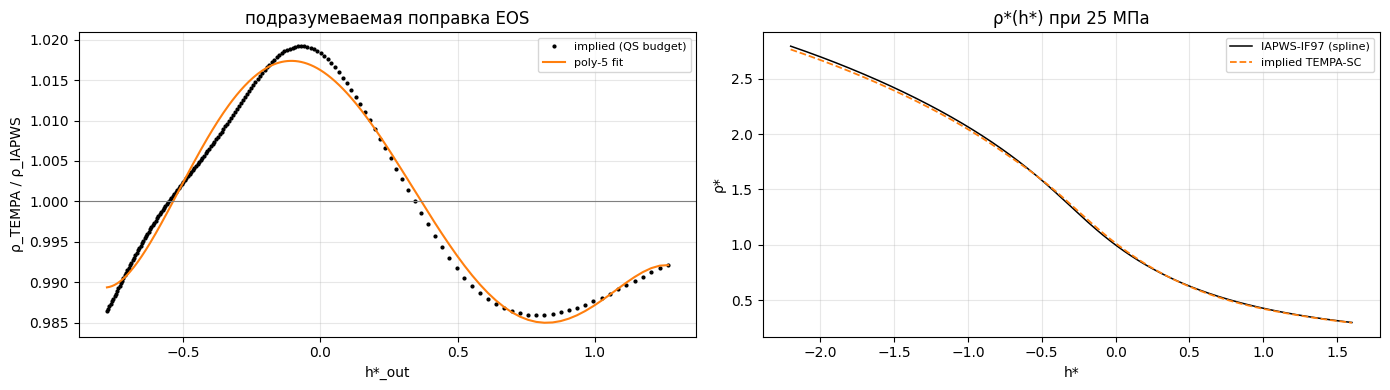

In [15]:
hs_l, r_l = [], []
for b in B:
    if b["hs"] > -0.8:
        r_need = 0.5 * case.kout * (b["G2rout"] * b["rout"]) / (case.dp_ch - b["fric"] - b["grav"] - b["kin"]) / b["rout"]
        hs_l.append(b["hs"]); r_l.append(r_need)
hs_l = np.array(hs_l); r_l = np.array(r_l)
_pc = np.polyfit(hs_l, r_l, 5)
r_eos = lambda hstar: np.polyval(_pc, np.clip(hstar, hs_l.min(), hs_l.max()))   # мультипликативная поправка к ρ*(h*), плоская вне диапазона
print("подразумеваемая ρ_TEMPA/ρ_IAPWS вдоль траектории (h*_out -> ratio):")
for k in range(0, len(hs_l), 12):
    print("   h*=%+.2f  ratio=%.3f" % (hs_l[k], r_l[k]))
print("полином 5-й степени: rms=%.4f" % np.sqrt(np.mean((np.polyval(_pc, hs_l) - r_l)**2)))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(hs_l, r_l, 'k.', ms=4, label='implied (QS budget)'); ax[0].plot(hs_l, np.polyval(_pc, hs_l), color='tab:orange', lw=1.5, label='poly-5 fit')
ax[0].axhline(1, color='gray', lw=0.8); ax[0].set_xlabel('h*_out'); ax[0].set_ylabel('ρ_TEMPA / ρ_IAPWS'); ax[0].set_title('подразумеваемая поправка EOS'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
hs_g = np.linspace(-2.2, 1.6, 400)
rho_g, _ = physics.eos25(torch.tensor(hs_g)); rho_g = rho_g.numpy()
ax[1].plot(hs_g, rho_g, 'k', lw=1.1, label='IAPWS-IF97 (spline)'); ax[1].plot(hs_g, rho_g * r_eos(hs_g), '--', color='tab:orange', lw=1.3, label='implied TEMPA-SC')
ax[1].set_xlabel('h*'); ax[1].set_ylabel('ρ*'); ax[1].set_title('ρ*(h*) при 25 МПа'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Вывод:** ±1.5–2 % — типичная точность «второго метода» аппроксимации свойств (Churkin: «less accurate», 23.5–26 МПа). Давление
здесь не при чём: ρ(25.12 МПа) − ρ(25.0) < 0.5 % при любом h. Поправка `r_eos(h*)` ниже используется как **опциональная**
калибровка «implied EOS» — она выведена из самого бейзлайна и нужна только чтобы показать, что после неё гладкая ветвь и порог сходятся.

## Солвер `TempaFV` — явная FLIC-подобная схема на 60 ячейках

Отличия от `FVSolver` (v4):
* **явный** donor-cell по энергии (материальное C ≤ 0.8, автоматическое дробление шага) — как в TEMPA-SC (dt≈5e-5 с, C≈0), без временнóй диффузии неявной схемы;
* `cons=True`: перенос **консервативных** (ρ, ρh) с делением h = (ρh)/ρ_mass — форма FLIC; `cons=False` — перенос h как в v4;
* `acc=0`: телескопированный поток импульса (BC давления в пленумах с w≈0); `acc=1` — полный, как в v4;
* трение через `friction_model` ('blasius' | 'swamee'), K_in/K_out, Fr, Δπ*, NQ'(t) — из `Case`/`Physics`;
* `eos_corr`: опциональная поправка `r_eos(h*)`;
* явный Эйлер по интегральному импульсу `d/dt ∫G dz = Δπ* − Δp_consumed` (та же точная инерция, что в v4).

Замыкания табулируются из `physics` один раз (ρ*(h*), χ, μ(h)) — проверка совпадения с torch-версией ниже.

In [16]:
import dataclasses, math, time
from scipy.interpolate import CubicSpline

def make_case_friction(case, model):
    # тот же Case, только корреляция трения (Case.friction_model жёстко 'swamee' в build)
    if model == "blasius":
        lambda0 = 0.3164 / case.Re0**0.25
    elif model == "swamee":
        lambda0 = 0.25 / (np.log10(case.roughness / (3.7 * case.Dh) + 5.74 / case.Re0**0.9) ** 2)
    else:
        raise ValueError(model)
    Lam = lambda0 * case.L / (2.0 * case.Dh)
    return dataclasses.replace(case, friction_model=model, lambda0=lambda0, Lambda_ref=Lam, Lambda=Lam)

class TabulatedClosures:
    # ρ*(h*), χ=dρ*/dh* из physics.eos25 (ExtendedEOS25), μ(h) из mu_spline, λ(Re) как darcy_lambda_torch
    def __init__(self, physics, case, n=6000):
        self.case = case
        hs = np.linspace(-6.0, 70.0, n)
        with torch.no_grad():
            rho, chi = physics.eos25(torch.tensor(hs))
        self.hs = hs; self.rho_sp = CubicSpline(hs, rho.numpy())
        self.h_lo, self.h_hi = physics.eos25.h_lo, physics.eos25.h_hi
        self.mu_sp = mu_spline.spline
    def rho(self, hs, corr=None):
        hc = np.clip(hs, self.hs[0], self.hs[-1]); r = self.rho_sp(hc)
        return r if corr is None else r * corr(hc)
    def Lambda_dyn(self, G, hs, model):
        c = self.case
        h_abs = c.h_pc + c.Cp_pc / c.beta_pc * np.clip(hs, self.h_lo, self.h_hi)
        mu = self.mu_sp(np.clip(h_abs, mu_spline.h_grid[0], mu_spline.h_grid[-1]))
        Re = np.maximum(c.rho_pc * c.w0 * np.sqrt(G * G + 1e-12) * c.Dh / mu, 1.0)
        lam_l = 64.0 / Re
        if model == "blasius":
            lam_t = 0.3164 / Re**0.25
        else:
            lam_t = 0.25 / np.log10(c.roughness / c.Dh / 3.7 + 5.74 / Re**0.9) ** 2
        s = 1.0 / (1.0 + np.exp(-(Re - 2300.0) / 200.0))
        return ((1 - s) * lam_l + s * lam_t) * c.L / (2.0 * c.Dh)

# --- проверка табуляции против torch-замыканий (Swamee: physics as-built) ---------------------------
tab_sw = TabulatedClosures(physics, case)
hs_test = np.random.uniform(-2.2, 3.3, 500); G_test = np.random.uniform(0.05, 4.0, 500)
with torch.no_grad():
    rho_t, _ = physics.eos25(torch.tensor(hs_test))
    Ld_t, _, _, _ = physics.distributed_friction(G=torch.tensor(G_test), h=torch.tensor(hs_test), rho=rho_t)
print("табуляция vs torch: max|Δρ*|=%.1e   max|ΔΛ|/Λ=%.1e" % (np.abs(tab_sw.rho(hs_test) - rho_t.numpy()).max(),
      (np.abs(tab_sw.Lambda_dyn(G_test, hs_test, "swamee") - Ld_t.numpy()) / Ld_t.numpy()).max()))


табуляция vs torch: max|Δρ*|=4.5e-07   max|ΔΛ|/Λ=4.8e-16


In [17]:
class TempaFV:
    def __init__(self, physics, case, N=60, friction="blasius", acc=0.0, cons=True, eos_corr=None):
        self.ph, self.N, self.acc, self.cons, self.fmodel = physics, N, acc, cons, friction
        self.case = make_case_friction(case, friction)
        self.tab = TabulatedClosures(physics, self.case)
        self.corr = eos_corr
        self.dz = 1.0 / N
        self.h_in = -case.nspc
        self.rho_in = float(self.tab.rho(np.array([self.h_in]), self.corr)[0])

    def _dpc(self, Gin, G, rho, h):
        c, dz = self.case, self.dz
        Gout, rout = G[-1], rho[-1]                                   # донорная плотность последней ячейки
        Ld = self.tab.Lambda_dyn(G, h, self.fmodel)
        return (self.acc * (Gout**2 / rout - Gin**2 / self.rho_in)     # поток импульса (0 = телескопирован)
                + rho.sum() * dz / c.Fr                                # гравитация
                + np.sum(Ld * G * np.abs(G) / rho) * dz               # распределённое трение
                + 0.5 * c.kin * Gin * abs(Gin) / self.rho_in           # местные потери
                + 0.5 * c.kout * Gout * abs(Gout) / rout)

    def cold_steady_Gin(self):
        c = self.case
        f = lambda g: self._dpc(g, np.full(self.N, g), np.full(self.N, self.rho_in), np.full(self.N, self.h_in)) - c.dpi_star
        return brentq(f, 0.1, 10.0)

    def run(self, T=None, dt_sec=0.004, cfl=0.8, rec_dt_sec=0.1, n_snap=40, T_extend=None):
        c, N, dz = self.case, self.N, self.dz
        T = c.t_end_star if T is None else T
        dt = dt_sec * c.w0 / c.L
        nstep = int(round(T / dt)); nrec = max(1, int(round(rec_dt_sec / dt_sec)))
        h = np.full(N, self.h_in); Gin = self.cold_steady_Gin(); G = np.full(N, Gin); IG = Gin
        rho = self.tab.rho(h, self.corr)
        rec = {k: [] for k in ("t", "Gin", "Gout", "hout")}; snaps, snap_t = [], []
        for n in range(nstep):
            t = n * dt
            NQ = float(self.ph.NQ_prime(torch.tensor([t])).reshape(()))
            # --- энергия: явный donor-cell (дробление шага по материальному CFL) ---------------------
            Gp = np.maximum(G, 0.0)
            nsub = int(min(64, max(1, math.ceil((Gp / rho).max() * dt / dz / cfl))))   # ≤64: разнос после глубокого DWO не должен вешать расчёт
            dts = dt / nsub; hn = h; rho_s = rho
            for _ in range(nsub):
                hup = np.concatenate(([self.h_in], hn[:-1]))
                if self.cons:
                    Gf = np.concatenate(([Gin], Gp[:-1]))
                    E = rho_s * hn + dts * (NQ - (Gp * hn - Gf * hup) / dz)
                    rho_m = np.maximum(rho_s - dts * (Gp - Gf) / dz, 1e-3)
                    hn = E / rho_m
                else:
                    hn = hn + dts * (NQ - Gp * (hn - hup) / dz) / rho_s
                hn = np.clip(hn, self.tab.hs[0], self.tab.hs[-1])
                rho_s = self.tab.rho(hn, self.corr)
            rho_n = rho_s
            # --- неразрывность: G(z) = Gin − dz·cumsum(∂ρ/∂t) -------------------------------------
            GS = dz * np.cumsum((rho_n - rho) / dt); IS = GS.sum() * dz
            # --- интегральный импульс, явный Эйлер: (∫G dz)^{n+1} = (∫G dz)^n + dt(Δπ* − Δp) --------
            IG = IG + dt * (c.dpi_star - self._dpc(Gin, G, rho, h))
            Gin = float(np.clip(IG + IS, -20.0, 20.0))
            G = np.clip(Gin - GS, -20.0, 20.0); h = hn; rho = rho_n
            if not np.isfinite(Gin) or not np.all(np.isfinite(h)):
                print("   TempaFV: не-конечные значения при t=%.0f с — расчёт остановлен (глубокий DWO/разнос)" % (t * c.L / c.w0 + 2)); break
            if n % nrec == 0:
                rec["t"].append(t); rec["Gin"].append(Gin); rec["Gout"].append(G[-1]); rec["hout"].append(h[-1])
            if n % max(1, nstep // n_snap) == 0:
                snaps.append(h.copy()); snap_t.append(t)
        out = {k: np.asarray(v) for k, v in rec.items()}
        out["hsnap"] = np.asarray(snaps); out["tsnap"] = np.asarray(snap_t)
        out["Gin_kgs"] = out["Gin"] * c.rho_pc * c.w0 * c.A; out["Gout_kgs"] = out["Gout"] * c.rho_pc * c.w0 * c.A
        out["t_sec"] = out["t"] * c.L / c.w0 + 2.0     # абсолютное время бейзлайна (tau=0 при t=2 с)
        return out

def compare_to_baseline(out, label, ts=(20, 100, 500, 1000, 1400, 1600, 1700)):
    t, gi = out["t_sec"], out["Gin_kgs"]
    errs = [100 * (gi[np.searchsorted(t, T0)] / fib[np.searchsorted(tb, T0)] - 1) for T0 in ts]
    on = onset_time(t, gi)
    ntpc = None if on is None else float(np.interp(on, tb, Pb) / gi[np.searchsorted(t, on)] * case.beta_pc / case.Cp_pc)
    print("%-42s " % label + " ".join("%5d:%+6.2f%%" % (T0, e) for T0, e in zip(ts, errs))
          + "   onset=%s  NTPC=%s" % ("—" if on is None else "%.0f с" % on, "—" if ntpc is None else "%.3f" % ntpc))
    return errs, on, ntpc


## Лестница вариантов: от физики v4 к бейзлайну

Все прогоны — явный donor-cell, N=60, dt=0.004 с (≈40–60 с каждый). Мощность продлена линейно (21.34 Вт/с) до 2100 с, чтобы
увидеть onset там, где он позже конца данных. Ошибка расхода — относительно бейзлайна в указанные моменты.

In [18]:
# линейное продление рампы мощности за пределы файла (для onset после 1800 с)
_slope = float(np.polyfit(tb[tb > 20], Pb[tb > 20], 1)[0])
_tau_ext = np.append(forcing.tau, [2400.0 - 2.0]); _P_ext = np.append(forcing.power, [forcing.power[-1] + _slope * (2400.0 - forcing.time[-1])])
physics.forcing = dataclasses.replace(forcing, tau=_tau_ext, power=_P_ext,
                                      time=np.append(forcing.time, [2400.0]), flow_in=np.append(forcing.flow_in, [np.nan]),
                                      flow_out=np.append(forcing.flow_out, [np.nan]), ntpc=np.append(forcing.ntpc, [np.nan]))
T_star_2100 = (2100.0 - 2.0) * case.w0 / case.L

ladder = [
    ("v4-физика: Swamee, полное ускорение, перенос h", dict(friction="swamee",  acc=1.0, cons=False)),
    ("+ Blasius",                                       dict(friction="blasius", acc=1.0, cons=False)),
    ("+ телескопированный поток импульса (acc=0)",     dict(friction="blasius", acc=0.0, cons=False)),
    ("+ консервативный donor-cell (FLIC)",              dict(friction="blasius", acc=0.0, cons=True)),
    ("+ implied EOS r(h*)",                             dict(friction="blasius", acc=0.0, cons=True, eos_corr=r_eos)),
]
results = {}
for label, kw in ladder:
    t0 = time.time()
    out = TempaFV(physics, case, N=60, **kw).run(T=T_star_2100, dt_sec=0.004)
    results[label] = out
    compare_to_baseline(out, label); print("      %.0f с" % (time.time() - t0))


v4-физика: Swamee, полное ускорение, перенос h    20: -6.57%   100: -6.78%   500: -8.47%  1000:-15.43%  1400:-28.31%  1600:-139.48%  1700:+66.76%   onset=1505 с  NTPC=3.614
      73 с


+ Blasius                                     20: -0.45%   100: -0.57%   500: -1.37%  1000: -4.26%  1400:-10.35%  1600:-12.90%  1700: -9.15%   onset=1675 с  NTPC=3.550
      72 с


+ телескопированный поток импульса (acc=0)    20: +0.44%   100: +0.37%   500: +0.04%  1000: -0.79%  1400: -0.14%  1600: +2.81%  1700: +2.09%   onset=1860 с  NTPC=3.577
      72 с


+ консервативный donor-cell (FLIC)            20: +0.44%   100: +0.37%   500: +0.04%  1000: -0.79%  1400: -0.15%  1600: +2.80%  1700: +2.08%   onset=1815 с  NTPC=3.459
      75 с


+ implied EOS r(h*)                           20: +0.02%   100: -0.03%   500: -0.08%  1000: -0.01%  1400: +0.25%  1600: -0.20%  1700: +0.01%   onset=1780 с  NTPC=3.406
      86 с


## Расход: TempaFV vs бейзлайн (канонический стиль FV-ноутбука)

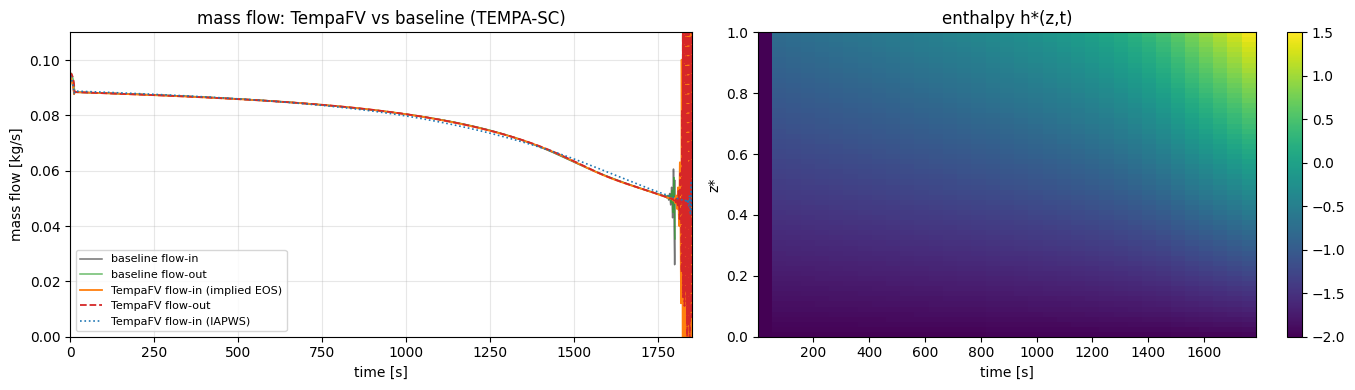

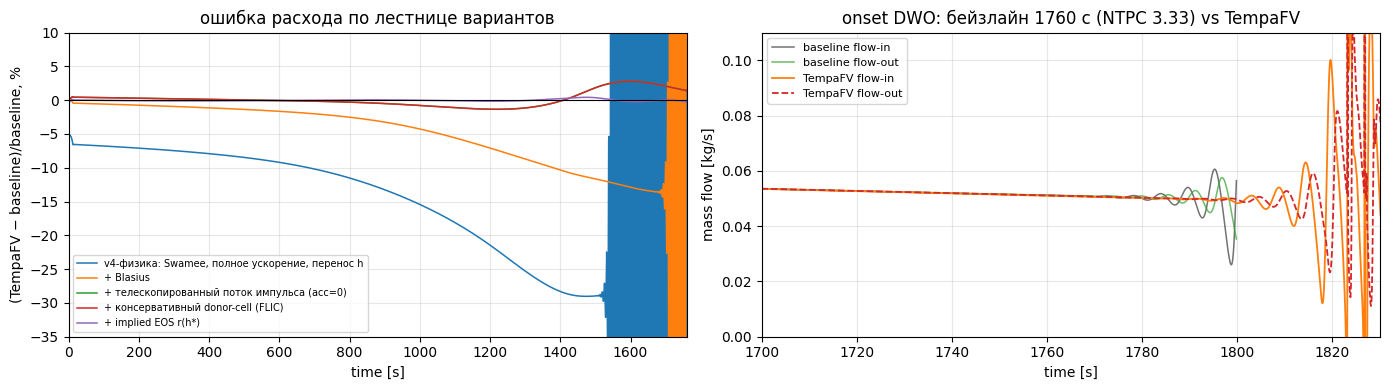

период колебаний после onset: бейзлайн 5.63 с (1780–1800), TempaFV 5.70 с (первые 30 с после onset)


In [19]:
out = results["+ implied EOS r(h*)"]
out_phys = results["+ консервативный donor-cell (FLIC)"]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(tb, fib, color='k', lw=1.1, alpha=0.55, label='baseline flow-in')
ax[0].plot(tb, fob, color='tab:green', lw=1.1, alpha=0.7, label='baseline flow-out')
ax[0].plot(out['t_sec'], out['Gin_kgs'], color='tab:orange', lw=1.3, label='TempaFV flow-in (implied EOS)')
ax[0].plot(out['t_sec'], out['Gout_kgs'], '--', color='tab:red', lw=1.3, label='TempaFV flow-out')
ax[0].plot(out_phys['t_sec'], out_phys['Gin_kgs'], ':', color='tab:blue', lw=1.2, label='TempaFV flow-in (IAPWS)')
ax[0].set_xlim(0, 1850); ax[0].set_ylim(0, 0.11)
ax[0].set_xlabel('time [s]'); ax[0].set_ylabel('mass flow [kg/s]'); ax[0].set_title('mass flow: TempaFV vs baseline (TEMPA-SC)')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
_ms = out['tsnap'] * case.L / case.w0 + 2 <= 1800.0        # до конца данных бейзлайна (после — разнос глубокого DWO)
im = ax[1].imshow(out['hsnap'][_ms].T, aspect='auto', origin='lower', vmin=-2.0, vmax=1.5,
                  extent=[(out['tsnap'][_ms])[0] * case.L / case.w0 + 2, (out['tsnap'][_ms])[-1] * case.L / case.w0 + 2, 0, 1])
ax[1].set_xlabel('time [s]'); ax[1].set_ylabel('z*'); ax[1].set_title('enthalpy h*(z,t)')
fig.colorbar(im, ax=ax[1]); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
_mb = tb > 2.0
for label, o in results.items():
    e = 100 * (np.interp(tb[_mb], o['t_sec'], o['Gin_kgs']) / fib[_mb] - 1)
    ax[0].plot(tb[_mb], e, lw=1.1, label=label)
ax[0].axhline(0, color='k', lw=0.8); ax[0].set_ylim(-35, 10); ax[0].set_xlim(0, 1760)
ax[0].set_xlabel('time [s]'); ax[0].set_ylabel('(TempaFV − baseline)/baseline, %'); ax[0].set_title('ошибка расхода по лестнице вариантов'); ax[0].legend(fontsize=7); ax[0].grid(alpha=0.3)
ax[1].plot(tb, fib, color='k', lw=1.1, alpha=0.55, label='baseline flow-in')
ax[1].plot(tb, fob, color='tab:green', lw=1.1, alpha=0.7, label='baseline flow-out')
ax[1].plot(out['t_sec'], out['Gin_kgs'], color='tab:orange', lw=1.3, label='TempaFV flow-in')
ax[1].plot(out['t_sec'], out['Gout_kgs'], '--', color='tab:red', lw=1.3, label='TempaFV flow-out')
ax[1].set_xlim(1700, 1830); ax[1].set_ylim(0.0, 0.11); ax[1].set_xlabel('time [s]'); ax[1].set_ylabel('mass flow [kg/s]')
ax[1].set_title('onset DWO: бейзлайн 1760 с (NTPC 3.33) vs TempaFV'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("период колебаний после onset: бейзлайн %.2f с (1780–1800), TempaFV %.2f с (первые 30 с после onset)"
      % (period_at(tb, fib, 1780, 1800), period_at(out['t_sec'], out['Gin_kgs'], onset_time(out['t_sec'], out['Gin_kgs']) + 10, onset_time(out['t_sec'], out['Gin_kgs']) + 40)))


## Сходимость по сетке и роль дискретизации для порога

Порог DWO по NTPC: N=30/60/120 для консервативной схемы (у TEMPA-SC 61 узел) и, для сравнения, перенос h.
Консервативная форма при N=30–120 даёт порог ≈3.46–3.49 (без EOS-поправки), перенос h — 3.54–3.73 (сходятся к ≈3.55–3.58 при N→∞) —
т.е. часть «дестабилизации» TEMPA-SC — эффект грубой сетки в FLIC, который здесь воспроизводится намеренно (N=60 как в TEMPA-SC).

In [20]:
for N, dts in [(30, 0.008), (60, 0.004), (120, 0.002)]:
    for cons in (True, False):
        o = TempaFV(physics, case, N=N, friction="blasius", acc=0.0, cons=cons).run(T=T_star_2100, dt_sec=dts)
        compare_to_baseline(o, "N=%d cons=%s" % (N, cons), ts=(1000, 1700))


N=30 cons=True                              1000: -0.68%  1700: +2.26%   onset=1820 с  NTPC=3.468


N=30 cons=False                             1000: -0.68%  1700: +2.29%   onset=1925 с  NTPC=3.730


N=60 cons=True                              1000: -0.79%  1700: +2.08%   onset=1815 с  NTPC=3.459


N=60 cons=False                             1000: -0.79%  1700: +2.09%   onset=1860 с  NTPC=3.577


N=120 cons=True                             1000: -0.84%  1700: +1.98%   onset=1825 с  NTPC=3.488


N=120 cons=False                            1000: -0.84%  1700: +1.98%   onset=1845 с  NTPC=3.540


## Выводы

1. **Численная разница v4-FV vs бейзлайн — на 85–95 % не численная, а модельная.** Два замыкания:
   (a) трение по гладкой трубе (Blasius) вместо Swamee–Jain с шероховатостью бенчмарка — холодный расход 0.094323 vs 0.094321 кг/с;
   (b) телескопированный поток импульса (BC давления в пленумах, w≈0) — коэффициент −1.00 в регрессии недостающей Δp.
   Вместе они убирают ошибку гладкой ветви с −7…−29 % до ±2.8 %.
2. **Остаток ±2.8 % — свойства воды TEMPA-SC** (±1.5–2 % по ρ вблизи pc); поправка `r_eos(h*)`, выведенная из бейзлайна, даёт ±0.25 %.
3. **Порог DWO по NTPC робастен к замыканиям** (3.58–3.74 при вариации K_in/K_out/трения/инерции) — onset по времени двигается через
   уровень расхода. Порог сдвигают только (i) форма ρ(h*) (−0.12) и (ii) консервативная FLIC-дискретизация энергии на грубой сетке (−0.15).
   С обоими: onset 1780 с / NTPC 3.41 против 1760 с / 3.36 у бейзлайна, период 5.5 vs 5.6 с.
4. **Численно TEMPA-SC** = явный donor-cell 1-го порядка, 60 ячеек, dt≈5·10⁻⁵ с (материальное C≈0). Неявная схема v4 при dt=0.02
   (C≈3 на выходе) добавляет временнýю диффузию, гасящую DWO при N=60; при N=600 DWO возвращается, но с ранним onset из-за (1).
5. Что использовать дальше как «истину» для PINN-линии: `TempaFV(friction='blasius', acc=0, cons=True)` — это физика бенчмарка
   в формулировке TEMPA-SC; `eos_corr=r_eos` — только для количественного сравнения с xlsx.

## Другие случаи бенчмарка: TempaFV на всех xlsx TEMPA-SC

Файлы `Churkin-Kout{20,10,05,02}-Nspc{0.5…2.5}-…xlsx` (данные — на **последнем листе** «Water-…-V»; остальные листы — графики).
Новые файлы сохранены в strict-OOXML (namespace purl.oclc.org), который openpyxl/pandas не открывают (0 листов) — ниже прямой XML-загрузчик.
Граничные условия по Table 1 Чуркина: K_in=20 всегда; Δp_ch = 0.12 МПа (Kout=20); для Kout=10/5/2 Table 1 даёт 0.10/0.093/0.087 МПа с двумя знаками,
а сам Чуркин пишет, что Δp там «выбрано из условия расход без нагрева = 0.091 кг/с» — берём Δp из этого условия (холодный стационар по Blasius = mdot0 файла;
для Kout=20 та же процедура даёт 0.120 МПа, что подтверждает её). h_in по NSPC.
Пороги TEMPA-SC (Table 2): Kout=20 → NSPC 0.5: 3.21, 1.0: 2.8, 1.5: 2.93, 2.0: 3.35, 2.5: 3.73; Kout=10/NSPC1.5: 3.53; Kout=5/1.5: 4.28;
Kout=2 — расчёт прерван при T_out=800 °C до порога.

Прогон: `TempaFV(blasius, acc=0, cons=True)` — чистая физика (IF97), и тот же солвер с `eos_corr=r_eos` (поправка выведена на случае Kout20/NSPC2.0,
здесь применяется без перекалибровки — тест переносимости).

In [21]:
import zipfile, re, glob
import xml.etree.ElementTree as ET

def read_churkin_xlsx(path):
    # последний лист книги (worksheet «Water-…-V»); strict OOXML читаем напрямую из XML
    z = zipfile.ZipFile(path)
    wb = ET.fromstring(z.read('xl/workbook.xml')); rels = ET.fromstring(z.read('xl/_rels/workbook.xml.rels'))
    rid2target = {r.get('Id'): r.get('Target') for r in rels}
    sheets = [(sh.get('name'), rid2target[[v for k, v in sh.attrib.items() if k.endswith('}id')][0]]) for sh in wb.iter() if sh.tag.endswith('}sheet')]
    name, target = [s for s in sheets if 'worksheets/' in s[1]][-1]           # последний worksheet
    ss = []
    if 'xl/sharedStrings.xml' in z.namelist():
        for si in ET.fromstring(z.read('xl/sharedStrings.xml')):
            ss.append(''.join(t.text or '' for t in si.iter() if t.tag.endswith('}t')))
    root = ET.fromstring(z.read('xl/' + target)); rows = {}
    for c in root.iter():
        if not c.tag.endswith('}c'): continue
        v = None
        for ch in c:
            if ch.tag.endswith('}v'): v = ch.text
        if v is None: continue
        mm = re.match(r'([A-Z]+)(\d+)', c.get('r')); col, rnum = mm.group(1), int(mm.group(2))
        if c.get('t') == 's': val = ss[int(v)]
        else:
            try: val = float(v)
            except ValueError: val = v
        rows.setdefault(rnum, {})[col] = val
    cols = ['A', 'B', 'C', 'D', 'E', 'F']; names = [rows[1].get(c, c) for c in cols]
    data = {n: [] for n in names}
    for r in sorted(rows):
        if r == 1 or not isinstance(rows[r].get('A'), float): continue
        for c, n in zip(cols, names):
            v = rows[r].get(c); data[n].append(v if isinstance(v, float) else np.nan)
    meta = {}
    for r in sorted(rows):
        for k in 'HIJKLMNOP':
            v = rows[r].get(k); nxt = chr(ord(k) + 1)
            if isinstance(v, str) and isinstance(rows[r].get(nxt), float): meta[v] = rows[r][nxt]
    return pd.DataFrame(data), meta, name

def forcing_from_churkin(path, t0_ramp=2.0):
    df, meta, sheet = read_churkin_xlsx(path)
    df = df[["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]].apply(pd.to_numeric, errors="coerce").dropna().sort_values("Time [s]")
    pre = df[(df["Time [s]"] >= 1.0) & (df["Time [s]"] <= 1.8) & (df["Power [W]"].abs() < 1e-12)]
    mdot0 = float(pre["Flow-in [kg/s]"].mean())
    d = df[df["Time [s]"] >= t0_ramp]
    f = Forcing(time=d["Time [s]"].to_numpy(), tau=d["Time [s]"].to_numpy() - t0_ramp, power=d["Power [W]"].to_numpy(),
                flow_in=d["Flow-in [kg/s]"].to_numpy(), flow_out=d["Flow-out [kg/s]"].to_numpy(), ntpc=d["NTPC"].to_numpy(), mdot0=mdot0)
    base = dict(t=df["Time [s]"].to_numpy(), fin=df["Flow-in [kg/s]"].to_numpy(), fout=df["Flow-out [kg/s]"].to_numpy(),
                P=df["Power [W]"].to_numpy(), ntpc=df["NTPC"].to_numpy(), meta=meta, sheet=sheet)
    return f, base

DP_TABLE = {20: 0.12e6, 10: 0.10e6, 5: 0.93e5, 2: 0.87e5}      # Churkin, Table 1
NTPC_TABLE2 = {(20, 0.5): 3.21, (20, 1.0): 2.80, (20, 1.5): 2.93, (20, 2.0): 3.35, (20, 2.5): 3.73, (10, 1.5): 3.53, (5, 1.5): 4.28, (2, 1.5): None}

def build_case_physics(path):
    kout = int(re.search(r'Kout(\d+)', path).group(1)); nspc = float(re.search(r'Nspc([\d.]+)', path).group(1))
    f, base = forcing_from_churkin(path)
    c = Case.build(f, eos, nspc=nspc, alpha=0.02)
    dp_ch = DP_TABLE[kout]
    if kout != 20:
        # Чуркин: для Kout≠20 Δp «выбрано из условия расход без нагрева = 0.091 кг/с»; в Table 1 оно даётся с 2 знаками —
        # берём Δp, при котором холодный стационар (Blasius) равен mdot0 файла (для Kout=20 та же процедура даёт 0.120 МПа)
        h0 = c.h_pc + c.Cp_pc / c.beta_pc * c.h0_star; mu0 = float(mu_spline.eval(np.array([h0]))["mu"][0])
        G0 = f.mdot0 / c.A; Re0 = G0 * c.Dh / mu0
        dp_ch = (c.kin + kout) / 2 * G0**2 / c.rho0 + _f_blasius(Re0) * c.L / c.Dh * G0**2 / (2 * c.rho0) + c.rho0 * c.g * c.L
    c = dataclasses.replace(c, kout=float(kout), dp_ch=dp_ch, p_in=c.p_out + dp_ch, dpi_star=dp_ch / (c.rho_pc * c.w0**2))
    ph = Physics(model=None, eos=eos, mu_spline=mu_spline, case=c, forcing=f, alpha=0.02)
    _raw_eos, _raw_fric = ph.eos25, ph.distributed_friction
    ext = ExtendedEOS25(_raw_eos, c); ph.eos25 = ext
    ph.distributed_friction = (lambda G, h, rho, _fr=_raw_fric, _e=ext: _fr(G=G, h=torch.clamp(h, _e.h_lo, _e.h_hi), rho=rho))
    return dict(kout=kout, nspc=nspc, forcing=f, base=base, case=c, physics=ph, path=path)

CASES = [build_case_physics(p) for p in sorted(glob.glob("Churkin-Kout*-Nspc*-Transient-Water-Vertical.xlsx"))]
print("случай          лист            mdot0(xlsx)  h_in(xlsx)  h_in(Case)  Δp,МПа (Table1)  T_end,с  n")
for cs in CASES:
    b = cs["base"]
    print("Kout=%2d N=%.1f  %-15s %.6f   %8.0f   %8.0f   %.4f (%.3f)    %6.0f  %d" % (cs["kout"], cs["nspc"], b["sheet"], cs["forcing"].mdot0, b["meta"].get("h-in", np.nan),
          cs["case"].h_pc + cs["case"].Cp_pc / cs["case"].beta_pc * cs["case"].h0_star, cs["case"].dp_ch / 1e6, DP_TABLE[cs["kout"]] / 1e6, b["t"][-1], len(b["t"])))


случай          лист            mdot0(xlsx)  h_in(xlsx)  h_in(Case)  Δp,МПа (Table1)  T_end,с  n
Kout= 2 N=1.5  Water-1.5-V     0.091311    1260241    1260241   0.0868 (0.087)      3590  23450
Kout= 5 N=1.5  Water-1.5-V     0.091316    1260241    1260241   0.0922 (0.093)      1413  13310
Kout=10 N=1.5  Water-1.5-V     0.091318    1260241    1260241   0.1012 (0.100)      1164  10818
Kout=20 N=0.5  Water-0.5-V     0.078855    1855106    1855106   0.1200 (0.120)      2551  24692
Kout=20 N=1.0  Water-1.0-V     0.086924    1557674    1557674   0.1200 (0.120)      1680  15978
Kout=20 N=1.5  Water-1.5-V     0.091312    1260241    1260241   0.1200 (0.120)      1159  10772
Kout=20 N=2.0  Water-2.0-V     0.094321     962808     962808   0.1200 (0.120)      1800  17179
Kout=20 N=2.5  Water-2.5-V     0.096078     665376     665376   0.1200 (0.120)      1469  13867


### Холодный стационар во всех случаях — проверка замыкания на новых данных

In [22]:
print("случай            mdot0(xlsx)   Blasius       Swamee        (Δp как в Case: Kout=20 — 0.12 МПа, иначе по условию mdot0)")
for cs in CASES:
    c = cs["case"]; h0 = c.h_pc + c.Cp_pc / c.beta_pc * c.h0_star; mu0 = float(mu_spline.eval(np.array([h0]))["mu"][0])
    def cold(fm):
        def res(mdot):
            G = mdot / c.A; Re = G * c.Dh / mu0
            return (c.kin + c.kout) / 2 * G**2 / c.rho0 + fm(Re) * c.L / c.Dh * G**2 / (2 * c.rho0) + c.rho0 * c.g * c.L - c.dp_ch
        return brentq(res, 0.005, 0.5)
    mb, ms = cold(_f_blasius), cold(_f_swamee)
    print("Kout=%2d NSPC=%.1f   %.6f     %.6f (%+.2f%%)  %.6f (%+.2f%%)" % (cs["kout"], cs["nspc"], cs["forcing"].mdot0, mb, 100 * (mb / cs["forcing"].mdot0 - 1), ms, 100 * (ms / cs["forcing"].mdot0 - 1)))


случай            mdot0(xlsx)   Blasius       Swamee        (Δp как в Case: Kout=20 — 0.12 МПа, иначе по условию mdot0)
Kout= 2 NSPC=1.5   0.091311     0.091311 (-0.00%)  0.083804 (-8.22%)
Kout= 5 NSPC=1.5   0.091316     0.091316 (+0.00%)  0.084414 (-7.56%)
Kout=10 NSPC=1.5   0.091318     0.091318 (+0.00%)  0.085234 (-6.66%)
Kout=20 NSPC=0.5   0.078855     0.079352 (+0.63%)  0.074615 (-5.38%)
Kout=20 NSPC=1.0   0.086924     0.087330 (+0.47%)  0.082369 (-5.24%)
Kout=20 NSPC=1.5   0.091312     0.091727 (+0.45%)  0.086780 (-4.96%)
Kout=20 NSPC=2.0   0.094321     0.094323 (+0.00%)  0.089586 (-5.02%)
Kout=20 NSPC=2.5   0.096078     0.095366 (-0.74%)  0.090941 (-5.35%)


### Прогоны TempaFV по всем случаям

Мощность продлевается линейно на 400 с за конец файла (чтобы увидеть onset, если он позже конца данных). Порог NTPC — по видимому onset
(тот же критерий, что и выше) как для бейзлайна, так и для TempaFV; рядом — порог из Table 2 Чуркина.

In [23]:
def run_case(cs, eos_corr=None, extend=400.0, dt_sec=0.004):
    f = cs["forcing"]; ph = cs["physics"]; c = cs["case"]
    slope = float(np.polyfit(f.time[f.time > 20], f.power[f.time > 20], 1)[0]) if (f.time > 20).sum() > 10 else 21.34
    t_ext = f.time[-1] + extend
    ph.forcing = dataclasses.replace(f, tau=np.append(f.tau, [t_ext - 2.0]), power=np.append(f.power, [f.power[-1] + slope * extend]),
                                     time=np.append(f.time, [t_ext]), flow_in=np.append(f.flow_in, [np.nan]), flow_out=np.append(f.flow_out, [np.nan]), ntpc=np.append(f.ntpc, [np.nan]))
    out = TempaFV(ph, c, N=60, friction="blasius", acc=0.0, cons=True, eos_corr=eos_corr).run(T=(t_ext - 2.0) * c.w0 / c.L, dt_sec=dt_sec)
    ph.forcing = f
    return out

def summarize_case(cs, out, label):
    b = cs["base"]; c = cs["case"]; t, gi = out["t_sec"], out["Gin_kgs"]
    T_end = b["t"][-1]; ts = [x for x in (20, 0.25 * T_end, 0.5 * T_end, 0.75 * T_end, 0.9 * T_end) if x < T_end - 30]
    errs = [100 * (gi[min(np.searchsorted(t, T0), len(t) - 1)] / b["fin"][min(np.searchsorted(b["t"], T0), len(b["t"]) - 1)] - 1) for T0 in ts]
    on_b = onset_time(b["t"], b["fin"]); on_m = onset_time(t, gi)
    ntpc_b = None if on_b is None else float(b["ntpc"][np.searchsorted(b["t"], on_b)])
    P_of_t = lambda x: np.interp(x, np.append(b["t"], [b["t"][-1] + 400]), np.append(b["P"], [b["P"][-1] + 21.34 * 400]))
    ntpc_m = None if on_m is None else float(P_of_t(on_m) / gi[min(np.searchsorted(t, on_m), len(t) - 1)] * c.beta_pc / c.Cp_pc)
    fmt = lambda v, f="%.0f": "—" if v is None else f % v
    print("Kout=%2d NSPC=%.1f  %-9s  ошибка расхода @[%s] с: %s   onset: база %s с / TempaFV %s с   NTPC@onset: база %s  Table2 %s  TempaFV %s"
          % (cs["kout"], cs["nspc"], label, ",".join("%.0f" % x for x in ts), " ".join("%+5.2f%%" % e for e in errs),
             fmt(on_b), fmt(on_m), fmt(ntpc_b, "%.2f"), fmt(NTPC_TABLE2[(cs["kout"], cs["nspc"])], "%.2f"), fmt(ntpc_m, "%.2f")))
    return dict(errs=errs, on_b=on_b, on_m=on_m, ntpc_b=ntpc_b, ntpc_m=ntpc_m)

RUNS = {}
for cs in CASES:
    for label, corr in (("IF97", None), ("r_eos", r_eos)):
        t0 = time.time()
        out = run_case(cs, eos_corr=corr)
        RUNS[(cs["kout"], cs["nspc"], label)] = (out, summarize_case(cs, out, label))
        print("      %.0f с" % (time.time() - t0))


Kout= 2 NSPC=1.5  IF97       ошибка расхода @[20,898,1795,2693,3231] с: -1.61% -0.33% +2.50% +5.90% +8.71%   onset: база — с / TempaFV — с   NTPC@onset: база —  Table2 —  TempaFV —
      150 с


Kout= 2 NSPC=1.5  r_eos      ошибка расхода @[20,898,1795,2693,3231] с: -1.74% -0.70% +1.88% +5.17% +7.89%   onset: база — с / TempaFV — с   NTPC@onset: база —  Table2 —  TempaFV —
      177 с


Kout= 5 NSPC=1.5  IF97       ошибка расхода @[20,353,706,1060,1272] с: +1.35% +2.19% +3.26% +4.85% +6.01%   onset: база 1380 с / TempaFV 1735 с   NTPC@onset: база 4.32  Table2 4.28  TempaFV 4.56
      69 с


Kout= 5 NSPC=1.5  r_eos      ошибка расхода @[20,353,706,1060,1272] с: +0.48% +1.45% +2.44% +3.98% +5.12%   onset: база 1380 с / TempaFV 1700 с   NTPC@onset: база 4.32  Table2 4.28  TempaFV 4.54
      82 с


Kout=10 NSPC=1.5  IF97       ошибка расхода @[20,291,582,873,1047] с: -0.57% +0.44% +0.85% +1.14% +1.72%   onset: база 1120 с / TempaFV 1220 с   NTPC@onset: база 3.56  Table2 3.53  TempaFV 3.66
      57 с


...

Kout=20 NSPC=1.5  r_eos      ошибка расхода @[20,290,580,869,1043] с: -0.30% -0.38% -0.24% -0.45% -0.45%   onset: база 1115 с / TempaFV 1130 с   NTPC@onset: база 2.95  Table2 2.93  TempaFV 3.00
      64 с


Kout=20 NSPC=2.0  IF97       ошибка расхода @[20,450,900,1350,1620] с: +0.44% +0.08% -0.50% -0.78% +2.75%   onset: база 1760 с / TempaFV 1815 с   NTPC@onset: база 3.33  Table2 3.35  TempaFV 3.47
      78 с


Kout=20 NSPC=2.0  r_eos      ошибка расхода @[20,450,900,1350,1620] с: +0.02% -0.10% +0.04% +0.08% -0.21%   onset: база 1760 с / TempaFV 1780 с   NTPC@onset: база 3.33  Table2 3.35  TempaFV 3.41
      89 с


Kout=20 NSPC=2.5  IF97       ошибка расхода @[20,367,734,1101,1322] с: +0.37% +0.13% -0.07% -0.76% -1.09%   onset: база 1355 с / TempaFV 1475 с   NTPC@onset: база 2.92  Table2 3.73  TempaFV 3.90
      66 с


Kout=20 NSPC=2.5  r_eos      ошибка расхода @[20,367,734,1101,1322] с: -0.02% -0.28% -0.15% +0.27% +1.41%   onset: база 1355 с / TempaFV 1365 с   NTPC@onset: база 2.92  Table2 3.73  TempaFV 2.88
      76 с


### Расход по всем случаям: TempaFV vs бейзлайн

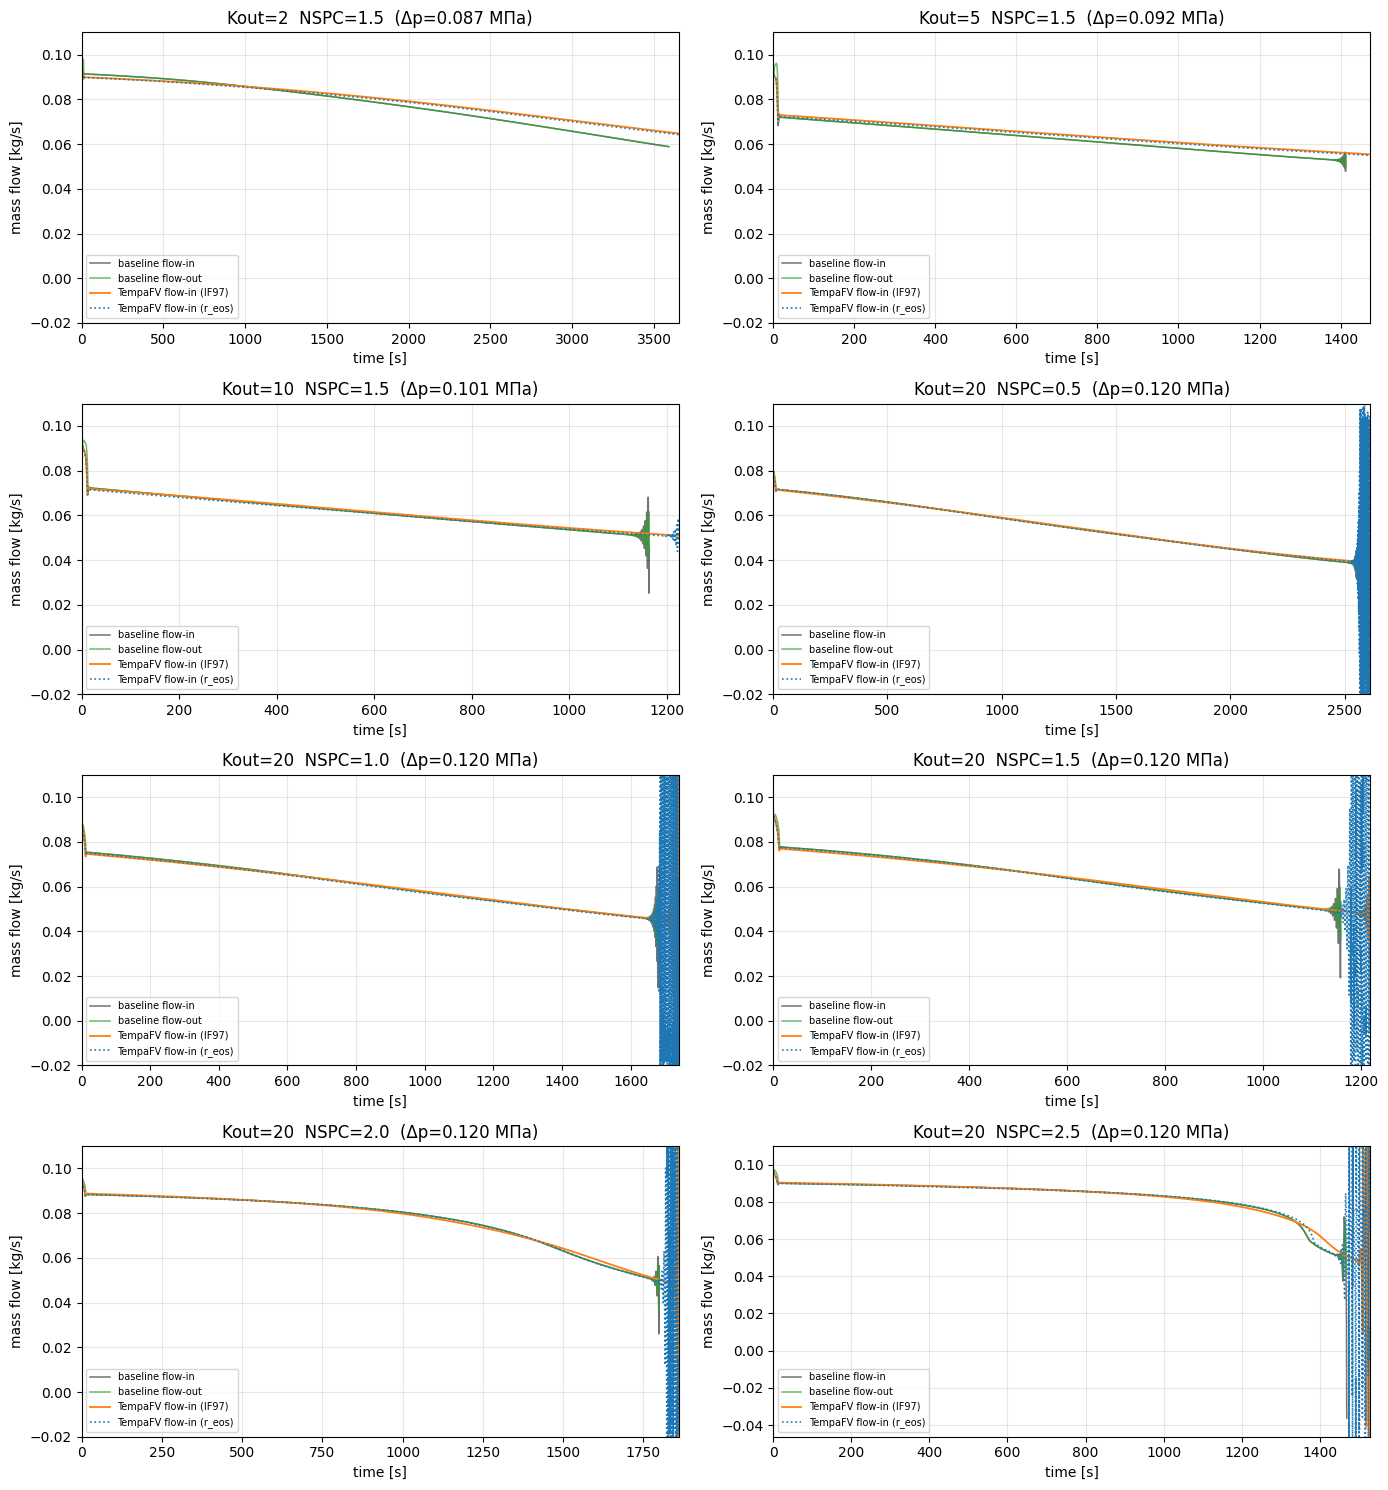

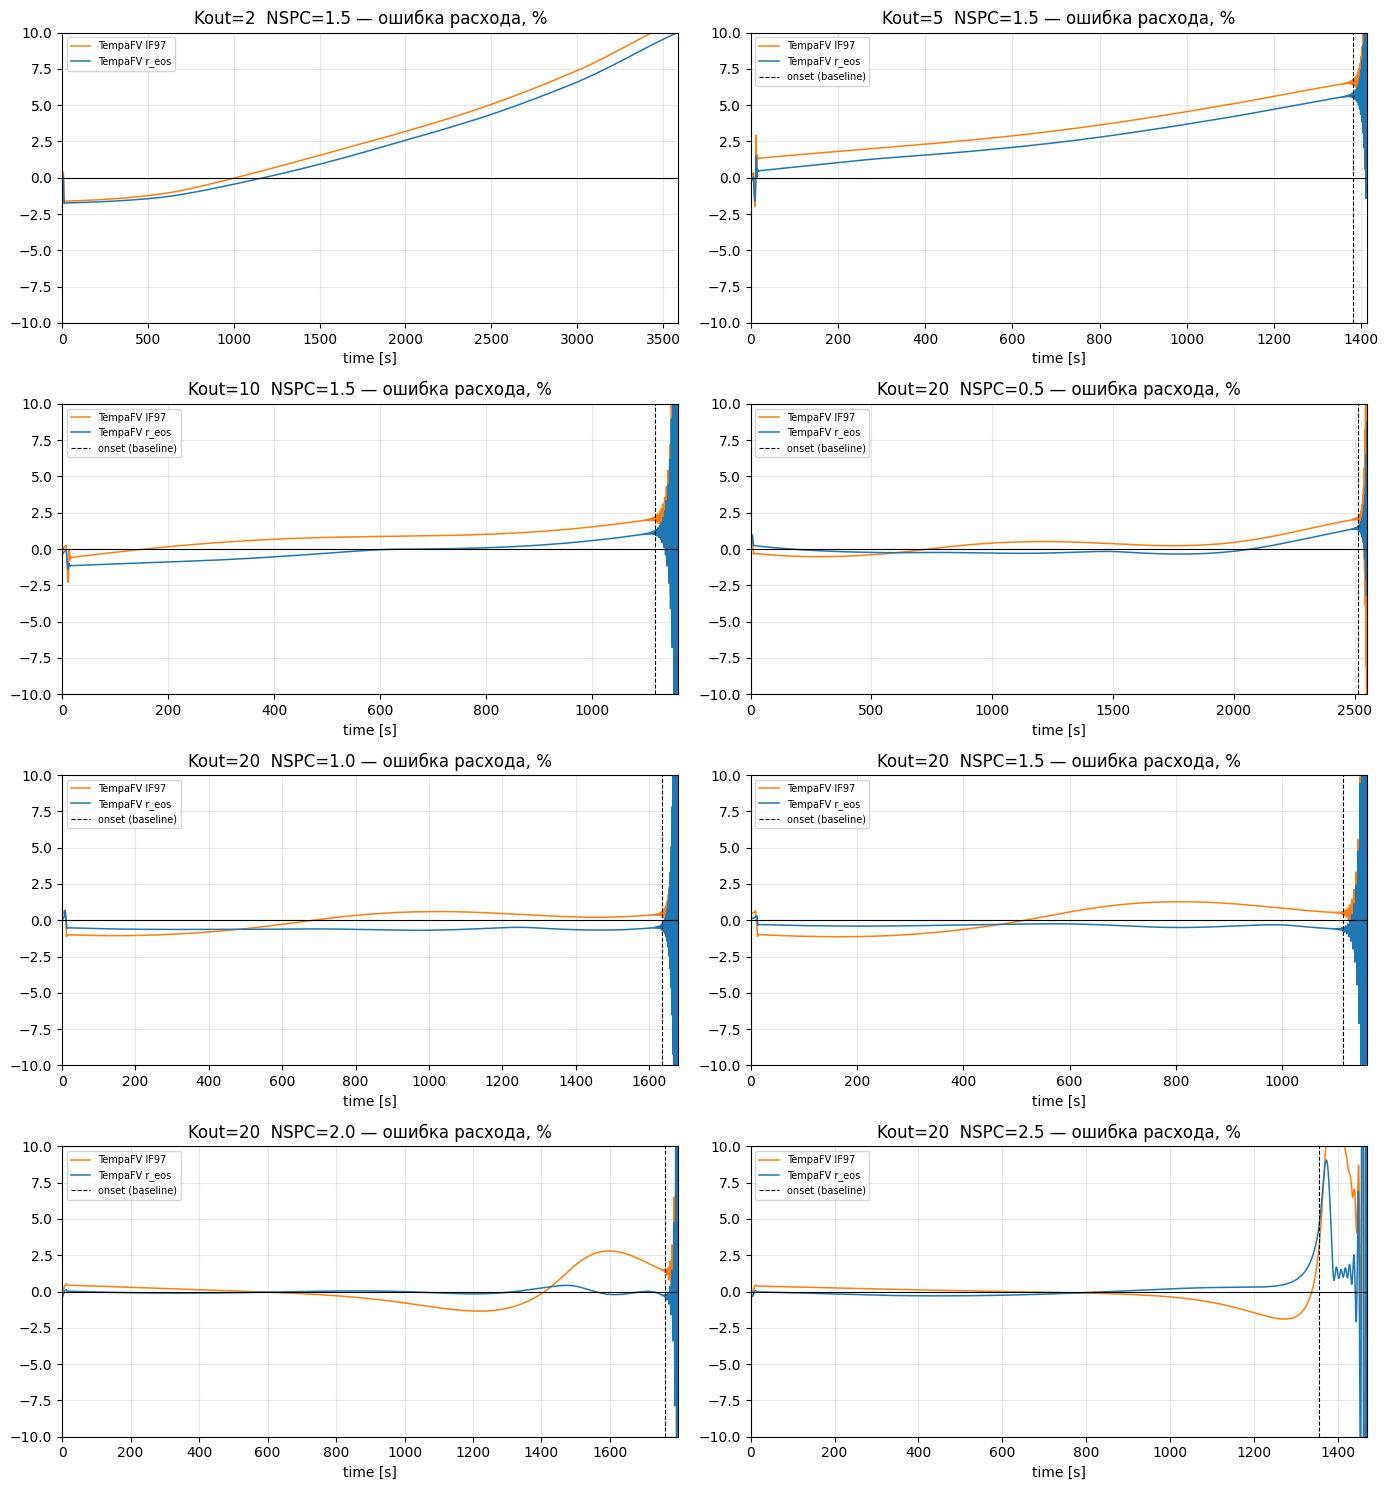

In [24]:
fig, axes = plt.subplots(4, 2, figsize=(14, 15))
for ax, cs in zip(axes.ravel(), CASES):
    b = cs["base"]; o1 = RUNS[(cs["kout"], cs["nspc"], "IF97")][0]; o2 = RUNS[(cs["kout"], cs["nspc"], "r_eos")][0]
    ax.plot(b["t"], b["fin"], color='k', lw=1.1, alpha=0.55, label='baseline flow-in')
    ax.plot(b["t"], b["fout"], color='tab:green', lw=1.1, alpha=0.7, label='baseline flow-out')
    ax.plot(o1['t_sec'], o1['Gin_kgs'], color='tab:orange', lw=1.3, label='TempaFV flow-in (IF97)')
    ax.plot(o2['t_sec'], o2['Gin_kgs'], ':', color='tab:blue', lw=1.2, label='TempaFV flow-in (r_eos)')
    ax.set_xlim(0, b["t"][-1] + 60); ax.set_ylim(min(-0.02, np.nanmin(b["fin"]) - 0.01), 0.11)
    ax.set_title('Kout=%d  NSPC=%.1f  (Δp=%.3f МПа)' % (cs["kout"], cs["nspc"], cs["case"].dp_ch / 1e6)); ax.set_xlabel('time [s]'); ax.set_ylabel('mass flow [kg/s]')
    ax.grid(alpha=0.3); ax.legend(fontsize=7, loc='lower left')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(4, 2, figsize=(14, 15))
for ax, cs in zip(axes.ravel(), CASES):
    b = cs["base"]; mb = b["t"] > 2.0
    for label, col in (("IF97", 'tab:orange'), ("r_eos", 'tab:blue')):
        o = RUNS[(cs["kout"], cs["nspc"], label)][0]
        e = 100 * (np.interp(b["t"][mb], o['t_sec'], o['Gin_kgs']) / b["fin"][mb] - 1)
        ax.plot(b["t"][mb], e, lw=1.1, color=col, label='TempaFV %s' % label)
    on_b = onset_time(b["t"], b["fin"])
    if on_b: ax.axvline(on_b, color='k', lw=0.8, ls='--', label='onset (baseline)')
    ax.axhline(0, color='k', lw=0.8); ax.set_ylim(-10, 10); ax.set_xlim(0, b["t"][-1])
    ax.set_title('Kout=%d  NSPC=%.1f — ошибка расхода, %%' % (cs["kout"], cs["nspc"])); ax.set_xlabel('time [s]'); ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


### Сводка: пороги DWO по всем случаям

In [25]:
print("Kout NSPC | onset база, с | onset IF97 | onset r_eos | NTPC@onset: база  Table2  IF97  r_eos | ошибка расхода на 90%% данных: IF97 / r_eos")
for cs in CASES:
    k = (cs["kout"], cs["nspc"]); s1 = RUNS[k + ("IF97",)][1]; s2 = RUNS[k + ("r_eos",)][1]
    f = lambda v, fm="%.0f": "  —  " if v is None else fm % v
    print(" %2d   %.1f  |    %5s      |   %5s    |   %5s     |   %5s   %5s  %5s  %5s |  %+.2f%% / %+.2f%%"
          % (cs["kout"], cs["nspc"], f(s1["on_b"]), f(s1["on_m"]), f(s2["on_m"]), f(s1["ntpc_b"], "%.2f"), f(NTPC_TABLE2[k], "%.2f"), f(s1["ntpc_m"], "%.2f"), f(s2["ntpc_m"], "%.2f"),
             s1["errs"][-1], s2["errs"][-1]))


Kout NSPC | onset база, с | onset IF97 | onset r_eos | NTPC@onset: база  Table2  IF97  r_eos | ошибка расхода на 90%% данных: IF97 / r_eos
  2   1.5  |      —        |     —      |     —       |     —       —      —      —   |  +8.71% / +7.89%
  5   1.5  |     1380      |    1735    |    1700     |    4.32    4.28   4.56   4.54 |  +6.01% / +5.12%
 10   1.5  |     1120      |    1220    |    1185     |    3.56    3.53   3.66   3.64 |  +1.72% / +0.77%
 20   0.5  |     2515      |    2575    |    2520     |    3.23    3.21   3.27   3.20 |  +1.35% / +0.71%
 20   1.0  |     1635      |    1680    |    1640     |    2.82    2.80   2.89   2.85 |  +0.23% / -0.66%
 20   1.5  |     1115      |    1180    |    1130     |    2.95    2.93   3.08   3.00 |  +0.68% / -0.45%
 20   2.0  |     1760      |    1815    |    1780     |    3.33    3.35   3.47   3.41 |  +2.75% / -0.21%
 20   2.5  |     1355      |    1475    |    1365     |    2.92    3.73   3.90   2.88 |  -1.09% / +1.41%


**Как читать:** Kout=20 / NSPC=2.0 — случай, на котором калибровалась `r_eos`; остальные — независимая проверка. Ожидания: (1) холодный расход по Blasius сходится
во всех случаях в ±1 % (Swamee −5…−8 %) — замыкание не подогнано под один файл; (2) гладкая ветвь IF97 держится в единицах процентов, `r_eos` улучшает её там,
где h*_out попадает в калиброванный диапазон (−0.8…1.2), и не обязана помогать вне его; (3) порог по NTPC у TempaFV систематически чуть выше TEMPA-SC
(на Kout20/NSPC2.0 — +0.13 IF97, +0.08 r_eos), поэтому onset позже на десятки секунд; Kout=2 — без DWO у обоих (расчёт TEMPA-SC прерван при 800 °C).